In [60]:
# Standard library imports
import os
import sys
import time
import math
import random
import collections
from collections import deque
import itertools

# Scientific computing
import numpy as np
import pandas as pd

# Graph library
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
from matplotlib import pyplot, patches

# Optimization
import gurobipy as gp
from gurobipy import GRB

np.random.seed(42)
random.seed(10)

# Helpers

In [61]:
def suppress_print():
    sys._stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

def resume_print():
    sys.stdout.close()
    sys.stdout = sys._stdout

In [62]:
def time_exceeded(start_time, max_time):
    return max_time is not None and (time.time() - start_time) > max_time

In [63]:
def create_pa_graph(N, c, seed: int | None = None, init_nodes: int | None = None, init_mode: str = "complete"):

    rng = np.random.default_rng(seed)

    M = (1, 2, 3, 4)

    if init_mode == "complete":
        G = nx.complete_graph(init_nodes)

    elif init_mode == "tree":
        G = nx.random_tree(init_nodes, seed=seed)

    else:
        raise ValueError("init_mode deve essere 'complete' o 'tree'")

    for u in range(init_nodes, N):
        G.add_node(u)

        m = int(rng.choice(M))

        existing = np.array(list(G.nodes()))
        existing = existing[existing != u]
        m = min(m, len(existing))

        degrees = np.array([G.degree(v) for v in existing], dtype=float)

        s = degrees.sum()
        probs = degrees / s

        targets = rng.choice(existing, size=m, replace=False, p=probs)

        for v in targets:
            G.add_edge(u, int(v))

    if c <= 0:
        raise ValueError("c must be a positive integer.")

    k_max = int(np.ceil(N / c))
    values = list(range(max(2, c), k_max * c + 1, c))

    theta = {v: int(rng.choice(values)) for v in G.nodes()}
    nx.set_node_attributes(G, theta, name="theta")

    return G, theta

In [64]:
def make_subset_connected(g, x, use_thetas=0, thetas = None):
    s = set(x)
    
    while True:
        H = g.subgraph(s)
        comps = list(nx.connected_components(H))
        
        if len(comps) == 1:
            break
        
        # pick two components
        C1, C2 = comps[0], comps[1]
        
        # find shortest path between them in full graph
        u = next(iter(C1))
        v = next(iter(C2))
        path = nx.shortest_path(g, u, v)
        
        # nodes to add (excluding endpoints already in S)
        to_add = [x for x in path if x not in s]
        
        # remove same number of arbitrary nodes to keep cardinality fixed
        to_remove = list(s - C1 - C2)[:len(to_add)]
        if use_thetas:
            to_remove = sorted(to_remove, key=lambda x: thetas[x])[:len(to_add)]
        
        for x in to_remove:
            s.remove(x)
        for x in to_add:
            s.add(x)

    return tuple(sorted(s))

In [65]:
def make_vector(init_seeds, N):
    x0 = np.zeros(N, dtype=float)
    x0[list(init_seeds)] = 1.0
    return x0

In [66]:
def connected_component_update(g, active_mask, thetas):

    N = g.number_of_nodes()
    actives = np.zeros(N, dtype=bool)

    if not np.any(active_mask):
        return actives

    active_nodes = np.flatnonzero(active_mask)
    H = g.subgraph(active_nodes)

    comp_id_of = {}
    comp_sizes = []
    cid = 0
    active_set = set(active_nodes)

    visited = set()
    for u in active_nodes:
        if u in visited:
            continue
        stack = [u]
        visited.add(u)
        comp_nodes = [u]

        while stack:
            x = stack.pop()
            for nbr in g.neighbors(x):
                if nbr in active_set and nbr not in visited:
                    visited.add(nbr)
                    stack.append(nbr)
                    comp_nodes.append(nbr)
        size = len(comp_nodes)
        comp_sizes.append(size)

        for w in comp_nodes:
            comp_id_of[w] = cid

        cid += 1

    comp_sizes = np.asarray(comp_sizes, dtype=int)
    inactive_nodes = np.flatnonzero(~active_mask)

    for v in inactive_nodes:
        touched_cids = set()

        for u in g.neighbors(v):
            if active_mask[u]:
                c = comp_id_of.get(u, None)
                if c is not None:
                    touched_cids.add(c)

        if touched_cids:
            total_reachable = int(comp_sizes[list(touched_cids)].sum())
            if total_reachable >= (int(thetas[v])-1):
                actives[v] = True

    return actives


In [67]:
def connected_component_spread(g, x0, thetas, max_t=1000):

    N = g.number_of_nodes()

    active = (x0 > 0).astype(bool)
    spread_hist = [int(np.sum(active))]

    for _ in range(max_t):
        prev = active.copy()
        new = connected_component_update(g, prev, thetas)
        active = prev | new

        if np.array_equal(active, prev):
            break
        spread_hist.append(int(np.sum(active)))

    final_spread = int(np.sum(active))
    final_x = np.zeros(N, dtype=float)
    final_x[active] = 1.0

    return final_spread, spread_hist, final_x

# Solvers

In [68]:
def SingleDiscount(g,thetas, K):

  W1 = nx.to_numpy_array(g)
  idx = []
  ddv = np.sum(W1 > 0, axis=0)
  tv = np.zeros(len(g.nodes))

  for _ in range(K):
    u = int(np.argmax(ddv))
    idx.append(u)
    v = list(np.nonzero(W1[u])[0])
    tv[v] += 1
    ddv[v] = ddv[v] - tv[v]
    ddv[u] = -1
    W1[u, :] = 0
    W1[:, u] = 0

  x = np.zeros(len(g.nodes))
  x[idx] = 1.0

  s = connected_component_spread(g, x, thetas, max_t=1000)[0]

  return s, x

In [69]:
def degree(g, N, K, thetas=None, connected=0):
    degs = np.array([g.degree(v) for v in g.nodes()])
    top_K = np.argsort(-degs)[:K]

    if connected:
        top_K = list(make_subset_connected(g, top_K, use_thetas=1, thetas=thetas))

    return make_vector(top_K, N)

def degree_threshold(g, N, K, thetas=None, connected=0):
    dt = np.array([g.degree(v) for v in g.nodes()])*np.array(list(thetas.values()))
    top_K = np.argsort(-dt)[:K]

    if connected:
        top_K = list(make_subset_connected(g, top_K, use_thetas=1, thetas=thetas))

    return make_vector(top_K, N)

def betweenness(g, N, K, thetas=None, connected=0):
    bets = nx.betweenness_centrality(g)
    bet_values = np.array([bets[v] for v in g.nodes()])
    top_K = np.argsort(-bet_values)[:K]

    if connected:
        top_K = list(make_subset_connected(g, top_K, use_thetas=1, thetas=thetas))

    return make_vector(top_K, N)

def degree_connected(g, N, K, thetas = None, connected = None):
    degs = np.array([g.degree(v) for v in g.nodes()])
    top_K = [np.argsort(-degs)[0]]
    neighbors = set(g.neighbors(top_K[0]))
    for _ in range(1, K):
        candidates = [v for v in g.nodes() if v not in top_K and v in neighbors]
        if not candidates:
            break
        degs = np.array([g.degree(v) for v in candidates])
        top_candidate = candidates[np.argsort(-degs)[0]]
        top_K.append(top_candidate)
        neighbors.update(g.neighbors(top_candidate))
    return make_vector(top_K, N)

In [70]:
def high_thetas_start(g, N, K, thetas = None, connected = 1):
    sorted_nodes = sorted(g.nodes(), key=lambda x: thetas[x], reverse=True)
    top_k = sorted_nodes[:K]
    if connected:
        top_k = list(make_subset_connected(g, top_k, use_thetas=1, thetas=thetas))
    return make_vector(top_k, N)

def SD_start(g, N, K, thetas = None, connected = 1):
    _, x0 = SingleDiscount(g, thetas, K)
    if connected:
        x0 = make_vector(make_subset_connected(g, list(np.nonzero(x0)[0]),use_thetas=1, thetas=thetas), N)
    return x0

def random_start(g, N, K, thetas = None, connected = 1):
    nodes = list(g.nodes())
    random.shuffle(nodes)
    top_k = nodes[:K]
    if connected:
        top_k = list(make_subset_connected(g, top_k, use_thetas=1, thetas=thetas))
    return make_vector(top_k, N)

In [71]:
def Neighbor_Search(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = 0):

    N = len(x0)
    X = [np.array(x0, dtype=float)]

    s = [connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]]
    r = 0
    xi_t = xi

    stop = False
    buffer = collections.deque(maxlen=buffer_dim)
    calls = 1
    start = time.time()
    history = [[s[-1], time.time() - start, calls]]

    def print_status(spread, done=False):
        if not verbose:
            return
        if done:
            print('\r' + f'Neighbors search... Done! Calls:{calls}. Time: {round(time.time()-start)}/{max_time} s. Influence spread: {spread}.' + ' ' * 20)
        else:
            print('\r' + f'Neighbors search... Calls:{calls}. Time: {round(time.time()-start)}/{max_time} s. Influence spread: {spread}.' + ' ' * 20, end='')

    def evaluate_neighbors(neighbors, s_base, x_base):
        nonlocal calls, stop

        s_temp = s_base
        x_temp = x_base

        for elem in neighbors:
            x_elem = np.zeros(N)
            x_elem[list(elem)] = 1.0
            key = tuple(x_elem)

            if key in buffer:
                continue
            if time_exceeded(start, max_time):
                stop = True
                break

            s_elem = connected_component_spread(g, x_elem, thetas=thetas, max_t=1000)[0]
            buffer.append(key)
            calls += 1
            print_status(s_temp)

            if s_elem > s_temp:
                history.append([s_elem, time.time() - start, calls])
                x_temp = x_elem
                s_temp = s_elem

                if s_elem == N:
                    return True, x_temp, s_temp

                if s_temp > (1 + xi_t) * s_base:
                    break

        return False, x_temp, s_temp

    print_status(s[-1])

    if s[-1] == N:
        print_status(s[-1], done=True)
        return s, X, history

    while (stop == False) and (r < 1000):
        if time_exceeded(start, max_time):
            stop = True
            break

        idx = set(np.nonzero(X[-1])[0])
        neighbors = []

        for elem1 in idx:
            for elem2 in set(g.neighbors(elem1)) - idx:
                temp = idx.copy()
                temp.add(elem2)
                temp.remove(elem1)
                neighbors.append(temp)

        found_opt, x_temp, s_temp = evaluate_neighbors(neighbors, s[-1], X[-1])
        if found_opt:
            X.append(x_temp)
            s.append(s_temp)
            print_status(s[-1], done=True)
            return s, X, history

        X.append(x_temp)
        s.append(s_temp)
        r += 1

        if s[-1] > (1 + xi_t) * s[-2]:
            continue

        elif s[-1] > s[-2]:
            xi_t = xi_t * delta

        else:
            X.pop()
            s.pop()

            idx = set(np.nonzero(X[-1])[0])
            idx_temp = set(range(N)) - idx
            neighbors = []

            for i in range(d // 2):
                for elem1 in itertools.combinations(idx, len(idx) - 1 - i):
                    for elem2 in itertools.combinations(idx_temp, i + 1):
                        neighbors.append(list(set(elem1) | set(elem2)))

            found_opt, x_temp, s_temp = evaluate_neighbors(neighbors, s[-1], X[-1])
            if found_opt:
                X.append(x_temp)
                s.append(s_temp)
                print_status(s[-1], done=True)
                return s, X, history

            X.append(x_temp)
            s.append(s_temp)
            r += 1

            if s[-1] == s[-2]:
                X.pop()
                s.pop()
                stop = True

            elif s[-1] > (1 + xi_t) * s[-2]:
                continue

            else:
                xi_t = xi_t * delta

    history.append([s[-1], time.time() - start, calls])
    print_status(s[-1], done=True)

    return s, X, history

In [72]:
def _max_comp_size_in_seedset(g, S):
    if len(S) == 0:
        return 0
    if len(S) == 1:
        return 1
    sub = g.subgraph(S)
    return max((len(c) for c in nx.connected_components(sub)), default=0)


def _meets_min_connectedness(g, S, min_conn_req):
    return _max_comp_size_in_seedset(g, S) >= int(min_conn_req)


def _x_from_seedset(N, S):
    x = np.zeros(N)
    x[list(S)] = 1.0
    return x


def _seedset_from_x(x):
    return set(np.nonzero(x)[0])


def _print_ns_status(verbose, calls, start, max_time, spread, done=False):
    if not verbose:
        return
    if done:
        print('\r' + f'Neighbors search... Done! Calls:{calls}. Time: {round(time.time()-start)}/{max_time} s. Influence spread: {spread}.' + ' ' * 20)
    else:
        print('\r' + f'Neighbors search... Calls:{calls}. Time: {round(time.time()-start)}/{max_time} s. Influence spread: {spread}.' + ' ' * 20, end='')


def _collect_marginal_gain_proposals(
    g,
    thetas,
    idx,
    min_conn,
    max_depth=2,
    max_candidates=20,
):
    proposals = {}
    seed_sub = g.subgraph(idx)
    max_candidates = max(1, int(max_candidates))

    for u_sel in list(idx):
        if u_sel not in seed_sub:
            continue

        comp_u = nx.node_connected_component(seed_sub, u_sel)
        h = len(comp_u)
        if h <= 1:
            continue

        depth_limit = h - 1 if max_depth is None else min(h - 1, int(max_depth))
        if depth_limit < 1:
            continue

        dist_map = nx.single_source_shortest_path_length(g, u_sel, cutoff=depth_limit)
        by_dist = {}
        for v, dist in dist_map.items():
            v = int(v)
            if dist == 0:
                continue
            by_dist.setdefault(dist, []).append(v)

        for radius in range(1, depth_limit + 1):
            cand = by_dist.get(radius, [])
            if not cand:
                continue

            cand = [v for v in cand if (v not in idx) and (thetas[v] > min_conn)]
            if not cand:
                continue

            for v in cand:
                mg_v = sum(1 for w in g.neighbors(v) if thetas[int(w)] <= radius)
                S_prov = (idx - {u_sel}) | {int(v)}
                if not _meets_min_connectedness(g, S_prov, min_conn):
                    continue
                key = tuple(sorted(S_prov))
                if key not in proposals or mg_v > proposals[key]:
                    proposals[key] = mg_v

    ordered = sorted(proposals.items(), key=lambda kv: kv[1], reverse=True)
    return [set(seedset) for seedset, _ in ordered[:max_candidates]]


def _generate_swap_neighbors(g, idx):
    neighbors = []
    for elem1 in idx:
        for elem2 in set(g.neighbors(elem1)) - idx:
            temp = idx.copy()
            temp.add(elem2)
            temp.remove(elem1)
            neighbors.append(temp)
    return neighbors


def _generate_d_exchange_neighbors(N, idx, d):
    neighbors = []
    idx_temp = set(range(N)) - idx
    for i in range(d // 2):
        for elem1 in itertools.combinations(idx, len(idx) - 1 - i):
            for elem2 in itertools.combinations(idx_temp, i + 1):
                neighbors.append(set(elem1) | set(elem2))
    return neighbors


def _filter_feasible_neighbors(g, neighbors, min_conn):
    return [S for S in neighbors if _meets_min_connectedness(g, S, min_conn)]


def _evaluate_neighbors(
    g,
    thetas,
    neighbors,
    s_base,
    x_base,
    N,
    xi_t,
    buffer,
    calls,
    stop,
    history,
    start,
    max_time,
    verbose,
    target_spread,
    early_break=True,
):
    s_temp = s_base
    x_temp = x_base

    for elem in neighbors:
        x_elem = _x_from_seedset(N, elem)
        key = tuple(x_elem)

        if key in buffer:
            continue
        if time_exceeded(start, max_time):
            stop = True
            break

        s_elem = connected_component_spread(g, x_elem, thetas=thetas, max_t=1000)[0]
        buffer.append(key)
        calls += 1
        _print_ns_status(verbose, calls, start, max_time, s_elem, done=False)

        if s_elem > s_temp:
            history.append([s_elem, time.time() - start, calls])
            x_temp = x_elem
            s_temp = s_elem

            if s_elem == target_spread:
                return True, x_temp, s_temp, calls, stop
            if early_break and s_temp > (1 + xi_t) * s_base:
                break

    return False, x_temp, s_temp, calls, stop


def NS_final(
    g,
    thetas,
    x0,
    delta,
    xi,
    d,
    max_time,
    buffer_dim,
    verbose=0,
    min_conn=10,
    mg_max_depth=2,
    mg_size=20,
):
    N = len(x0)
    X = [np.array(x0, dtype=float)]

    s = [connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]]
    r = 0
    xi_t = xi
    target_spread = N

    K = int(np.count_nonzero(x0))

    stop = False
    buffer = collections.deque(maxlen=buffer_dim)
    calls = 1
    start = time.time()
    history = [[s[-1], time.time() - start, calls]]

    _print_ns_status(verbose, calls, start, max_time, s[-1], done=False)

    if s[-1] == target_spread:
        _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
        return s, X, history

    while (not stop) and (r < 1000):
        if time_exceeded(start, max_time):
            stop = True
            break

        idx = _seedset_from_x(X[-1])

        proposals = _collect_marginal_gain_proposals(
            g,
            thetas,
            idx,
            min_conn=min_conn,
            max_depth=mg_max_depth,
            max_candidates=mg_size,
        )

        if proposals:
            found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
                g,
                thetas,
                proposals,
                s[-1],
                X[-1],
                N=N,
                xi_t=xi_t,
                buffer=buffer,
                calls=calls,
                stop=stop,
                history=history,
                start=start,
                max_time=max_time,
                verbose=verbose,
                target_spread=target_spread,
                early_break=False,
            )

            if stop:
                break
            if found_opt:
                X.append(x_temp)
                s.append(s_temp)
                r += 1
                _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
                return s, X, history

            if s_temp > s[-1]:
                X.append(x_temp)
                s.append(s_temp)
                r += 1

                if s[-1] > (1 + xi_t) * s[-2]:
                    continue
                elif s[-1] > s[-2]:
                    xi_t = xi_t * delta
                continue

        neighbors = _generate_swap_neighbors(g, idx)
        neighbors = _filter_feasible_neighbors(g, neighbors, min_conn=min_conn)
        found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
            g,
            thetas,
            neighbors,
            s[-1],
            X[-1],
            N=N,
            xi_t=xi_t,
            buffer=buffer,
            calls=calls,
            stop=stop,
            history=history,
            start=start,
            max_time=max_time,
            verbose=verbose,
            target_spread=target_spread,
            early_break=True,
        )

        if found_opt:
            X.append(x_temp)
            s.append(s_temp)
            _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
            return s, X, history

        X.append(x_temp)
        s.append(s_temp)
        r += 1

        if s[-1] > (1 + xi_t) * s[-2]:
            continue
        elif s[-1] > s[-2]:
            xi_t = xi_t * delta
        else:
            X.pop()
            s.pop()

            idx = _seedset_from_x(X[-1])
            neighbors = _generate_d_exchange_neighbors(N, idx, d)
            neighbors = _filter_feasible_neighbors(g, neighbors, min_conn=min_conn)
            found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
                g,
                thetas,
                neighbors,
                s[-1],
                X[-1],
                N=N,
                xi_t=xi_t,
                buffer=buffer,
                calls=calls,
                stop=stop,
                history=history,
                start=start,
                max_time=max_time,
                verbose=verbose,
                target_spread=target_spread,
                early_break=True,
            )

            if found_opt:
                X.append(x_temp)
                s.append(s_temp)
                _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
                return s, X, history

            X.append(x_temp)
            s.append(s_temp)
            r += 1

            if s[-1] == s[-2]:
                X.pop()
                s.pop()
                stop = True
            elif s[-1] > (1 + xi_t) * s[-2]:
                continue
            else:
                xi_t = xi_t * delta

    history.append([s[-1], time.time() - start, calls])
    _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
    return s, X, history

In [73]:
def NS_last(
    g: nx.Graph,
    x0: np.ndarray,
    theta_vec: np.ndarray,
    *,
    d: int = 2,
    max_time: int = 120,
    buffer_dim: int = 5000,
    max_outer_iters: int = 1000,
    early_stop_spread: int | None = None,
    H_RADIUS: int = 30,
):


    N = len(x0)

    if early_stop_spread is None:
        early_stop_spread = N

    # numero di seed iniziali
    K = int(np.count_nonzero(x0))
    min_conn_req = K

    def x_from_seedset(S: set[int]) -> np.ndarray:
        x = np.zeros(N, dtype=float)
        x[list(S)] = 1.0
        return x

    def max_comp_size_in_seedset(S: set[int]) -> int:
        if len(S) <= 1:
            return len(S)
        sub = g.subgraph(S)
        return max((len(c) for c in nx.connected_components(sub)), default=0)

    def meets_min_connectedness(S: set[int]) -> bool:
        return max_comp_size_in_seedset(S) >= min_conn_req

  #usiamo questa funzione per fillare i gap per i nodi considerati a distanza maggiore di 1 
  #è abbastanza costosa dovendo calcolare lo shortest path dal seedst 
    def make_move(S: set[int], v: int) -> set[int] | None:
        """
        Dato il seedset corrente S (|S| = K) e un candidato v,
        costruisce un nuovo seedset S_new:

        - include v
        - è connesso nel sottografo indotto
        - ha cardinalità K
        - è ottenuto:
            * prendendo tutti i nodi di un cammino più corto tra v e S
            * riempiendo con nodi di S che non rompono la connettività
        """
        v = int(v)
        if v in S:
            # già seed, non serve
            return None

        # Trova il nodo di S più vicino a v e il cammino più corto
        try:
            lengths = nx.single_source_shortest_path_length(g, v)
        except Exception:
            return None

        candidates = [(lengths[u], u) for u in S if u in lengths]
        if not candidates:
            return None

        _, u_best = min(candidates, key=lambda t: t[0])

        try:
            path = nx.shortest_path(g, v, u_best)
        except nx.NetworkXNoPath:
            return None

        path_nodes = set(int(u) for u in path)

        # Se il cammino da solo richiede più di K nodi, non è fattibile
        if len(path_nodes) > K:
            return None

        # Core connesso iniziale: tutti i nodi del cammino
        S_new = set(path_nodes)

        # Possiamo ancora aggiungere nodi dell'old seedset
        remaining = list(S - S_new)

        # Riempiamo fino a K, aggiungendo solo nodi che mantengono la connettività
        while len(S_new) < K:
            added = False
            for u in list(remaining):
                # aggiungi u solo se ha almeno un vicino già in S_new
                for w in g.neighbors(u):
                    if int(w) in S_new:
                        S_new.add(int(u))
                        remaining.remove(u)
                        added = True
                        break
                if added:
                    break
            if not added:
                # non possiamo più aggiungere nodi senza creare componenti isolate
                break

        # se non siamo arrivati a K, scartiamo la move
        if len(S_new) != K:
            return None

        # sicurezza: controlla che sia connesso nell'indotto
        sub = g.subgraph(S_new)
        if not nx.is_connected(sub):
            return None

        return S_new

    # Stato iniziale
    X = [np.array(x0, dtype=float)]
    s0 = connected_component_spread(g, X[-1], theta_vec)[0]
    s = [s0]

    buffer = collections.deque(maxlen=buffer_dim)
    buffer.append(list(X[-1]))

    calls = 1
    start = time.time()
    r = 0
    stop = False

    history = [[s[-1], 0.0, calls]]

    while not stop and r < max_outer_iters:
        idx = set(np.nonzero(X[-1])[0])  # seedset corrente S
        improved = False

        for u_sel in list(idx):
            # raggio massimo: min tra H_RADIUS, K e N-1
            h = min(H_RADIUS, K, g.number_of_nodes() - 1)

            visited = {int(u_sel)}
            frontier = {int(u_sel)}

            mg_memory = deque(maxlen=5)
            tried_add_nodes = set()

            for radius in range(1, h + 1):
                next_frontier = set()
                for u in frontier:
                    for v in g.neighbors(u):
                        v = int(v)
                        if v not in visited:
                            next_frontier.add(v)

                if not next_frontier:
                    break

                visited |= next_frontier
                frontier = next_frontier

                cand = [v for v in frontier if v not in idx]
                if not cand:
                    mg_memory.append([])
                    continue

                layer_entries = []
                for v in cand:
                    mg_v = 0
                    for w in g.neighbors(v):
                        if theta_vec[int(w)] <= radius:
                            mg_v += 1
                    layer_entries.append((int(mg_v), int(v)))

                # ordina per margine decrescente, poi per id crescente
                layer_entries.sort(key=lambda t: (t[0], -t[1]), reverse=True)
                mg_memory.append(layer_entries)

                # migliore nel livello corrente
                best_current = None
                for mg_v, v in layer_entries:
                    if v not in tried_add_nodes:
                        best_current = (mg_v, v)
                        break

                if best_current is None:
                    continue

                # migliore globale negli ultimi livelli
                best_overall = None
                for entries in mg_memory:
                    for mg_v, v in entries:
                        if v in tried_add_nodes:
                            continue
                        if (
                            best_overall is None
                            or mg_v > best_overall[0]
                            or (mg_v == best_overall[0] and v < best_overall[1])
                        ):
                            best_overall = (mg_v, v)

                attempt_list = []
                if best_overall is not None:
                    attempt_list.append(best_overall[1])
                if best_current is not None and best_current[1] not in attempt_list:
                    attempt_list.append(best_current[1])

                for best_v in attempt_list:
                    best_v = int(best_v)
                    if best_v in tried_add_nodes:
                        continue
                    tried_add_nodes.add(best_v)

                    # NUOVA LOGICA: costruisci una move connessa che includa best_v
                    S_new = make_move(idx, best_v)
                    if S_new is None:
                        continue

                    x_prov = x_from_seedset(S_new)
                    if list(x_prov) in buffer:
                        continue

                    if time.time() - start >= max_time:
                        stop = True
                        break

                    s_prov = connected_component_spread(g, x_prov, theta_vec)[0]
                    buffer.append(list(x_prov))
                    calls += 1

                    if s_prov > s[-1]:
                        X.append(x_prov)
                        s.append(s_prov)
                        history.append([s_prov, time.time() - start, calls])
                        improved = True

                        if s_prov >= early_stop_spread:
                            stop = True
                        break

                if stop or improved:
                    break

            if stop or improved:
                break

        # Fase di vicinato combinatorio come fallback, invariata
        if not stop and not improved:
            idx = set(np.nonzero(X[-1])[0])
            idx_temp = set(range(N)) - idx
            neighbors = []

            for i in range(d // 2):
                for rem in itertools.combinations(idx, len(idx) - 1 - i):
                    for add in itertools.combinations(idx_temp, i + 1):
                        neighbors.append(set(rem) | set(add))

            s_temp = s[-1]
            x_temp = X[-1]

            for S_new in neighbors:
                if not meets_min_connectedness(S_new):
                    continue

                x_new = x_from_seedset(S_new)
                if list(x_new) in buffer:
                    continue

                if time.time() - start >= max_time:
                    stop = True
                    break

                s_new = connected_component_spread(g, x_new, theta_vec)[0]
                buffer.append(list(x_new))
                calls += 1

                if s_new > s_temp:
                    s_temp = s_new
                    x_temp = x_new
                    history.append([s_new, time.time() - start, calls])
                    if s_new >= early_stop_spread:
                        stop = True
                    break

            if not stop:
                if s_temp > s[-1]:
                    X.append(x_temp)
                    s.append(s_temp)
                else:
                    stop = True

        r += 1

        if time.time() - start >= max_time:
            stop = True

    history.append([s[-1], time.time() - start, calls])
    return s, X, history

In [78]:
def _make_move_connected_seedset(g, S, v, K):
    v = int(v)
    if v in S:
        return None

    try:
        lengths = nx.single_source_shortest_path_length(g, v)
    except Exception:
        return None

    candidates = [(lengths[u], u) for u in S if u in lengths]
    if not candidates:
        return None

    _, u_best = min(candidates, key=lambda t: t[0])

    try:
        path = nx.shortest_path(g, v, u_best)
    except nx.NetworkXNoPath:
        return None

    path_nodes = set(int(u) for u in path)
    if len(path_nodes) > K:
        return None

    S_new = set(path_nodes)
    remaining = list(S - S_new)

    while len(S_new) < K:
        added = False
        for u in list(remaining):
            for w in g.neighbors(u):
                if int(w) in S_new:
                    S_new.add(int(u))
                    remaining.remove(u)
                    added = True
                    break
            if added:
                break
        if not added:
            break

    if len(S_new) != K:
        return None

    sub = g.subgraph(S_new)
    if not nx.is_connected(sub):
        return None

    return S_new


def _mg_phase(
    g,
    thetas,
    idx,
    N,
    K,
    s_base,
    buffer,
    calls,
    history,
    start,
    max_time,
    verbose,
    target_spread,
    min_conn,
    mg_max_depth,
    mg_memory_len
):
    improved_mg = False
    stop = False
    x_temp = _x_from_seedset(N, idx)
    s_temp = s_base

    h = min(max(1, int(mg_max_depth)), K, g.number_of_nodes() - 1)
    mg_memory = collections.deque(maxlen=max(1, int(mg_memory_len)))
    tried_add_nodes = set()

    for u_sel in list(idx):
        visited = {int(u_sel)}
        frontier = {int(u_sel)}

        for radius in range(1, h + 1):
            next_frontier = set()
            for u in frontier:
                for v in g.neighbors(u):
                    v = int(v)
                    if v not in visited:
                        next_frontier.add(v)

            if not next_frontier:
                break

            visited |= next_frontier
            frontier = next_frontier

            cand = [v for v in frontier if v not in idx]
            if not cand:
                mg_memory.append([])
                continue

            layer_entries = []
            for v in cand:
                mg_v = sum(1 for w in g.neighbors(v) if thetas[int(w)] <= radius)
                layer_entries.append((int(mg_v), int(v)))

            layer_entries.sort(key=lambda t: (t[0], -t[1]), reverse=True)
            mg_memory.append(layer_entries)

            best_current = None
            for mg_v, v in layer_entries:
                if v not in tried_add_nodes:
                    best_current = (mg_v, v)
                    break

            if best_current is None:
                continue

            best_overall = None
            for entries in mg_memory:
                for mg_v, v in entries:
                    if v in tried_add_nodes:
                        continue
                    if (
                        best_overall is None
                        or mg_v > best_overall[0]
                        or (mg_v == best_overall[0] and v < best_overall[1])
                    ):
                        best_overall = (mg_v, v)

            attempt_list = []
            if best_overall is not None:
                attempt_list.append(best_overall[1])
            if best_current is not None and best_current[1] not in attempt_list:
                attempt_list.append(best_current[1])

            for best_v in attempt_list:
                best_v = int(best_v)
                if best_v in tried_add_nodes:
                    continue
                tried_add_nodes.add(best_v)

                S_new = _make_move_connected_seedset(g, idx, best_v, K)
                if S_new is None:
                    continue
                if not _meets_min_connectedness(g, S_new, min_conn):
                    continue

                x_prov = _x_from_seedset(N, S_new)
                key = tuple(x_prov)

                if key in buffer:
                    continue
                if time_exceeded(start, max_time):
                    stop = True
                    break

                s_prov = connected_component_spread(g, x_prov, thetas=thetas, max_t=1000)[0]
                buffer.append(key)
                calls += 1
                _print_ns_status(verbose, calls, start, max_time, s_prov, done=False)

                if s_prov > s_temp:
                    history.append([s_prov, time.time() - start, calls])
                    x_temp = x_prov
                    s_temp = s_prov
                    improved_mg = True

                    if s_prov == target_spread:
                        return True, improved_mg, x_temp, s_temp, calls, stop
                    break

            if stop or improved_mg:
                break

        if stop or improved_mg:
            break

    return False, improved_mg, x_temp, s_temp, calls, stop


def NS_final(
    g,
    thetas,
    x0,
    delta,
    xi,
    d,
    max_time,
    buffer_dim,
    verbose=0,
    min_conn=10,
    mg_max_depth=2,
    mg_memory_len=5,
):
    N = len(x0)
    X = [np.array(x0, dtype=float)]

    s = [connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]]
    r = 0
    xi_t = xi
    target_spread = N

    K = int(np.count_nonzero(x0))

    stop = False
    buffer = collections.deque(maxlen=buffer_dim)
    calls = 1
    start = time.time()
    history = [[s[-1], time.time() - start, calls]]

    _print_ns_status(verbose, calls, start, max_time, s[-1], done=False)

    if s[-1] == target_spread:
        _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
        return s, X, history

    while (not stop) and (r < 1000):
        if time_exceeded(start, max_time):
            stop = True
            break

        idx = _seedset_from_x(X[-1])

        found_opt, improved_mg, x_temp, s_temp, calls, mg_stop = _mg_phase(
            g,
            thetas,
            idx,
            N=N,
            K=K,
            s_base=s[-1],
            buffer=buffer,
            calls=calls,
            history=history,
            start=start,
            max_time=max_time,
            verbose=verbose,
            target_spread=target_spread,
            min_conn=min_conn,
            mg_max_depth=mg_max_depth,
            mg_memory_len=mg_memory_len,
        )
        if mg_stop:
            stop = True
            break

        if found_opt:
            X.append(x_temp)
            s.append(s_temp)
            _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
            return s, X, history

        if improved_mg:
            X.append(x_temp)
            s.append(s_temp)
            r += 1

            if s[-1] > (1 + xi_t) * s[-2]:
                continue
            elif s[-1] > s[-2]:
                xi_t = xi_t * delta
            continue

        neighbors = _generate_swap_neighbors(g, idx)
        neighbors = _filter_feasible_neighbors(g, neighbors, min_conn=min_conn)
        found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
            g,
            thetas,
            neighbors,
            s[-1],
            X[-1],
            N=N,
            xi_t=xi_t,
            buffer=buffer,
            calls=calls,
            stop=stop,
            history=history,
            start=start,
            max_time=max_time,
            verbose=verbose,
            target_spread=target_spread,
            early_break=True,
        )

        if found_opt:
            X.append(x_temp)
            s.append(s_temp)
            _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
            return s, X, history

        X.append(x_temp)
        s.append(s_temp)
        r += 1

        if s[-1] > (1 + xi_t) * s[-2]:
            continue
        elif s[-1] > s[-2]:
            xi_t = xi_t * delta
        else:
            X.pop()
            s.pop()

            idx = _seedset_from_x(X[-1])
            neighbors = _generate_d_exchange_neighbors(N, idx, d)
            neighbors = _filter_feasible_neighbors(g, neighbors, min_conn=min_conn)
            found_opt, x_temp, s_temp, calls, stop = _evaluate_neighbors(
                g,
                thetas,
                neighbors,
                s[-1],
                X[-1],
                N=N,
                xi_t=xi_t,
                buffer=buffer,
                calls=calls,
                stop=stop,
                history=history,
                start=start,
                max_time=max_time,
                verbose=verbose,
                target_spread=target_spread,
                early_break=True,
            )

            if found_opt:
                X.append(x_temp)
                s.append(s_temp)
                _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
                return s, X, history

            X.append(x_temp)
            s.append(s_temp)
            r += 1

            if s[-1] == s[-2]:
                X.pop()
                s.pop()
                stop = True
            elif s[-1] > (1 + xi_t) * s[-2]:
                continue
            else:
                xi_t = xi_t * delta

    history.append([s[-1], time.time() - start, calls])
    _print_ns_status(verbose, calls, start, max_time, s[-1], done=True)
    return s, X, history

In [ ]:
N = 1000
K = 60

delta = 0.5
xi = 0.1
d = 2
max_time = 60
buffer_dim = 5000
verbose = 0

for i in range(1):

    print(f'\n\n--- Instance {i} ---')
    g, thetas = create_pa_graph(N=N, c=1, seed=i, init_nodes=3, init_mode="complete")  

    x0 = high_thetas_start(g, N, K, thetas = thetas, connected = 1)
    s0 = connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]
    print(f'Initial spread: {s0}')
    s, x, history = Neighbor_Search(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = verbose)
    print(f'NS spread: {s[-1]}')
    s1, x1, history1 = NS_last(g, x0, thetas, max_time=max_time, H_RADIUS=10)
    print(f'NS_last spread: {s1[-1]}')



--- Instance 0 ---
Initial spread: 134
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
Marginal gain
CDS type
CDS type
CDS type
CDS type
Marginal gain
NS_last spread: 395


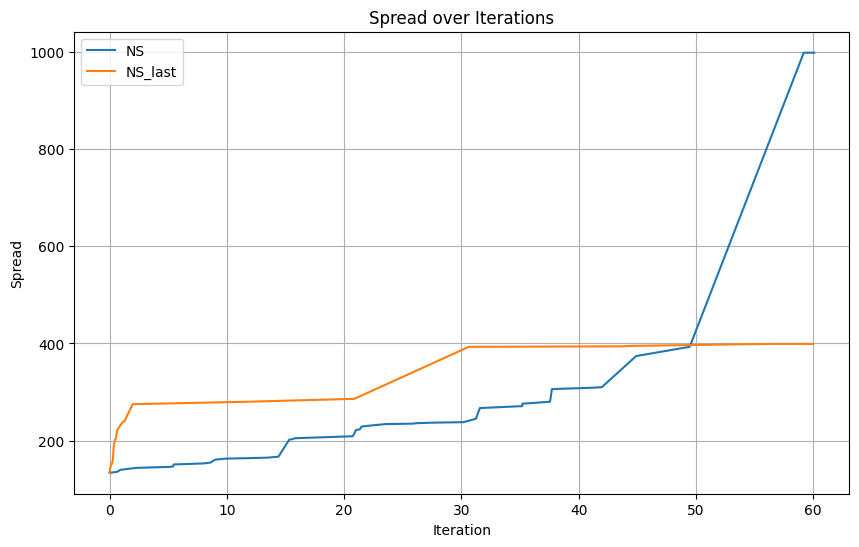

In [53]:
spread1 =  [h[0] for h in history]
spread2 =  [h[0] for h in history1]
times1 = [h[1] for h in history]
times2 = [h[1] for h in history1]
calls1 = [h[2] for h in history]
calls2 = [h[2] for h in history1]

plt.figure(figsize=(10, 6))
plt.plot(times1, spread1 , label='NS')
plt.plot(times2, spread2, label='NS_last')
plt.xlabel('Iteration')
plt.ylabel('Spread')
plt.title('Spread over Iterations')
plt.legend()
plt.grid()
plt.show()



--- Instance 2 ---
Initial spread: 270
NS spread: 1000
NS_last spread: 797


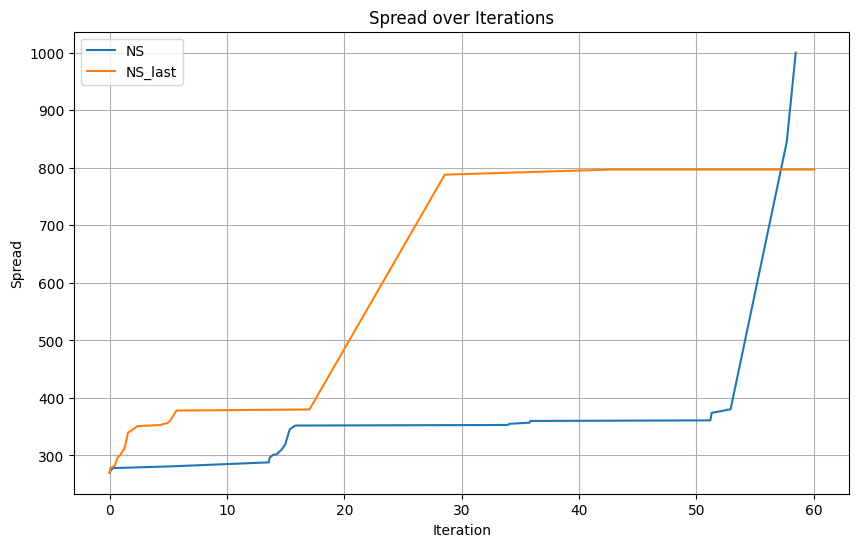

In [54]:
N = 1000
K = 60

delta = 0.5
xi = 0.1
d = 2
max_time = 60
buffer_dim = 5000
verbose = 0

for i in range(2,3):

    print(f'\n\n--- Instance {i} ---')
    g, thetas = create_pa_graph(N=N, c=1, seed=i, init_nodes=3, init_mode="complete")  

    x0 = high_thetas_start(g, N, K, thetas = thetas, connected = 1)
    s0 = connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]
    print(f'Initial spread: {s0}')
    s, x, history = Neighbor_Search(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = verbose)
    print(f'NS spread: {s[-1]}')
    s1, x1, history1 = NS_last(g, x0, thetas, max_time=max_time, H_RADIUS=10)
    print(f'NS_last spread: {s1[-1]}')

spread1 =  [h[0] for h in history]
spread2 =  [h[0] for h in history1]
times1 = [h[1] for h in history]
times2 = [h[1] for h in history1]
calls1 = [h[2] for h in history]
calls2 = [h[2] for h in history1]

plt.figure(figsize=(10, 6))
plt.plot(times1, spread1 , label='NS')
plt.plot(times2, spread2, label='NS_last')
plt.xlabel('Iteration')
plt.ylabel('Spread')
plt.title('Spread over Iterations')
plt.legend()
plt.grid()
plt.show()

In [81]:
N = 1000
K = 50

delta = 0.5
xi = 0.1
d = 2
max_time = 60
buffer_dim = 5000
verbose = 0

random.seed(42)
for i in range(10):

    print(f'\n\n--- Instance {i} ---')
    g, thetas = create_pa_graph(N=N, c=1, seed= i, init_nodes=3, init_mode="complete")  

    x0 = high_thetas_start(g, N, K, thetas = thetas, connected = 1)
    s0 = connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]
    print(f'Initial spread: {s0}')
    s, x, history = Neighbor_Search(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = verbose)
    print(f'NS spread: {s[-1]}')
    s, x, history = NS_last(g, x0, thetas, max_time=max_time, H_RADIUS=10)
    print(f'NS_last spread: {s[-1]}')
    s, x, history = NS_final(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose=0, min_conn=20, mg_max_depth=10)
    print(f'NS_final spread: {s[-1]}')



--- Instance 0 ---
Initial spread: 82
NS spread: 229
NS_last spread: 234
NS_final spread: 239


--- Instance 1 ---
Initial spread: 111
NS spread: 225
NS_last spread: 250
NS_final spread: 310


--- Instance 2 ---
Initial spread: 118
NS spread: 346
NS_last spread: 349
NS_final spread: 360


--- Instance 3 ---
Initial spread: 115
NS spread: 176
NS_last spread: 171
NS_final spread: 181


--- Instance 4 ---
Initial spread: 135
NS spread: 334
NS_last spread: 578
NS_final spread: 589


--- Instance 5 ---
Initial spread: 126
NS spread: 429
NS_last spread: 419
NS_final spread: 417


--- Instance 6 ---
Initial spread: 147
NS spread: 1000
NS_last spread: 320
NS_final spread: 1000


--- Instance 7 ---
Initial spread: 72
NS spread: 162
NS_last spread: 180
NS_final spread: 194


--- Instance 8 ---
Initial spread: 105
NS spread: 646
NS_last spread: 204
NS_final spread: 646


--- Instance 9 ---
Initial spread: 126
NS spread: 221
NS_last spread: 281
NS_final spread: 307


In [ ]:
N = 1000
K = 60

delta = 0.5
xi = 0.1
d = 2
max_time = 60
buffer_dim = 5000
verbose = 0

for i in range(10):

    print(f'\n\n--- Instance {i} ---')
    g, thetas = create_pa_graph(N=N, c=1, seed=i, init_nodes=3, init_mode="complete")  

    x0 = high_thetas_start(g, N, K, thetas = thetas, connected = 1)
    s0 = connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]
    print(f'Initial spread: {s0}')
    s, x, history = Neighbor_Search(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = verbose)
    print(f'NS spread: {s[-1]}')
    s, x, history = NS_last(g, x0, thetas, max_time=max_time, H_RADIUS=10)
    print(f'NS_last spread: {s[-1]}')
    s, x, history = NS_final(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose=0, min_conn=15, mg_max_depth=3, mg_size=30)
    print(f'NS_final spread: {s[-1]}')

In [ ]:
(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = 0)

def NS_last(
    g: nx.Graph,
    x0: np.ndarray,
    thetas: np.ndarray,
    d: int = 2,
    max_time: int = 120,
    buffer_dim: int = 5000,
    radius: int = 30,
    verbose = 0):

    N = len(x0)

    if early_stop_spread is None:
        early_stop_spread = N

    K = int(np.count_nonzero(x0))
    min_conn_req = K


    def max_comp_size_in_seedset(S: set[int]) -> int:
        if len(S) <= 1:
            return len(S)
        sub = g.subgraph(S)
        return max((len(c) for c in nx.connected_components(sub)), default=0)

    def meets_min_connectedness(S: set[int]) -> bool:
        return max_comp_size_in_seedset(S) >= min_conn_req


    def make_move(S: set[int], v: int) -> set[int] | None:
        """
        Dato il seedset corrente S (|S| = K) e un candidato v,
        costruisce un nuovo seedset S_new:

        - include v
        - è connesso nel sottografo indotto
        - ha cardinalità K
        - è ottenuto:
            * prendendo tutti i nodi di un cammino più corto tra v e S
            * riempiendo con nodi di S che non rompono la connettività
        """
        v = int(v)
        if v in S:
            # già seed, non serve
            return None

        # Trova il nodo di S più vicino a v e il cammino più corto
        try:
            lengths = nx.single_source_shortest_path_length(g, v)
        except Exception:
            return None

        candidates = [(lengths[u], u) for u in S if u in lengths]
        if not candidates:
            return None

        _, u_best = min(candidates, key=lambda t: t[0])

        try:
            path = nx.shortest_path(g, v, u_best)
        except nx.NetworkXNoPath:
            return None

        path_nodes = set(int(u) for u in path)

        # Se il cammino da solo richiede più di K nodi, non è fattibile
        if len(path_nodes) > K:
            return None

        # Core connesso iniziale: tutti i nodi del cammino
        S_new = set(path_nodes)

        # Possiamo ancora aggiungere nodi dell'old seedset
        remaining = list(S - S_new)

        # Riempiamo fino a K, aggiungendo solo nodi che mantengono la connettività
        while len(S_new) < K:
            added = False
            for u in list(remaining):
                # aggiungi u solo se ha almeno un vicino già in S_new
                for w in g.neighbors(u):
                    if int(w) in S_new:
                        S_new.add(int(u))
                        remaining.remove(u)
                        added = True
                        break
                if added:
                    break
            if not added:
                # non possiamo più aggiungere nodi senza creare componenti isolate
                break

        # se non siamo arrivati a K, scartiamo la move
        if len(S_new) != K:
            return None

        # sicurezza: controlla che sia connesso nell'indotto
        sub = g.subgraph(S_new)
        if not nx.is_connected(sub):
            return None

        return S_new

    # Stato iniziale
    X = [np.array(x0, dtype=float)]
    s0 = connected_component_spread(g, x0, thetas=thetas, max_t=1000)[0]
    s = [s0]

    buffer = collections.deque(maxlen=buffer_dim)
    buffer.append(list(X[-1]))

    calls = 1
    start = time.time()
    r = 0
    stop = False

    history = [[s[-1], 0.0, calls]]

    while not stop and r < 1000:
        idx = set(np.nonzero(X[-1])[0])  # seedset corrente S
        improved = False

        for u_sel in list(idx):
            # raggio massimo: min tra radius, K e N-1
            h = min(radius, K, g.number_of_nodes() - 1)

            visited = {int(u_sel)}
            frontier = {int(u_sel)}

            mg_memory = deque(maxlen=5)
            tried_add_nodes = set()

            for radius in range(1, h + 1):
                next_frontier = set()
                for u in frontier:
                    for v in g.neighbors(u):
                        v = int(v)
                        if v not in visited:
                            next_frontier.add(v)

                if not next_frontier:
                    break

                visited |= next_frontier
                frontier = next_frontier

                cand = [v for v in frontier if v not in idx]
                if not cand:
                    mg_memory.append([])
                    continue

                layer_entries = []
                for v in cand:
                    mg_v = 0
                    for w in g.neighbors(v):
                        if theta_vec[int(w)] <= radius:
                            mg_v += 1
                    layer_entries.append((int(mg_v), int(v)))

                # ordina per margine decrescente, poi per id crescente
                layer_entries.sort(key=lambda t: (t[0], -t[1]), reverse=True)
                mg_memory.append(layer_entries)

                # migliore nel livello corrente
                best_current = None
                for mg_v, v in layer_entries:
                    if v not in tried_add_nodes:
                        best_current = (mg_v, v)
                        break

                if best_current is None:
                    continue

                # migliore globale negli ultimi livelli
                best_overall = None
                for entries in mg_memory:
                    for mg_v, v in entries:
                        if v in tried_add_nodes:
                            continue
                        if (
                            best_overall is None
                            or mg_v > best_overall[0]
                            or (mg_v == best_overall[0] and v < best_overall[1])
                        ):
                            best_overall = (mg_v, v)

                attempt_list = []
                if best_overall is not None:
                    attempt_list.append(best_overall[1])
                if best_current is not None and best_current[1] not in attempt_list:
                    attempt_list.append(best_current[1])

                for best_v in attempt_list:
                    best_v = int(best_v)
                    if best_v in tried_add_nodes:
                        continue
                    tried_add_nodes.add(best_v)

                    # NUOVA LOGICA: costruisci una move connessa che includa best_v
                    S_new = make_move(idx, best_v)
                    if S_new is None:
                        continue

                    x_prov = x_from_seedset(S_new)
                    if list(x_prov) in buffer:
                        continue

                    if time.time() - start >= max_time:
                        stop = True
                        break

                    s_prov = influence_evaluation(g, x_prov, theta_vec)[0]
                    buffer.append(list(x_prov))
                    calls += 1

                    if s_prov > s[-1]:
                        X.append(x_prov)
                        s.append(s_prov)
                        history.append([s_prov, time.time() - start, calls])
                        improved = True

                        if s_prov >= early_stop_spread:
                            stop = True
                        break

                if stop or improved:
                    break

            if stop or improved:
                break

        # Fase di vicinato combinatorio come fallback, invariata
        if not stop and not improved:
            idx = set(np.nonzero(X[-1])[0])
            idx_temp = set(range(N)) - idx
            neighbors = []

            for i in range(d // 2):
                for rem in itertools.combinations(idx, len(idx) - 1 - i):
                    for add in itertools.combinations(idx_temp, i + 1):
                        neighbors.append(set(rem) | set(add))

            s_temp = s[-1]
            x_temp = X[-1]

            for S_new in neighbors:
                if not meets_min_connectedness(S_new):
                    continue

                x_new = x_from_seedset(S_new)
                if list(x_new) in buffer:
                    continue

                if time.time() - start >= max_time:
                    stop = True
                    break

                s_new = influence_evaluation(g, x_new, theta_vec)[0]
                buffer.append(list(x_new))
                calls += 1

                if s_new > s_temp:
                    s_temp = s_new
                    x_temp = x_new
                    history.append([s_new, time.time() - start, calls])
                    if s_new >= early_stop_spread:
                        stop = True
                    break

            if not stop:
                if s_temp > s[-1]:
                    X.append(x_temp)
                    s.append(s_temp)
                else:
                    stop = True

        r += 1

        if time.time() - start >= max_time:
            stop = True

    history.append([s[-1], time.time() - start, calls])
    return s, X, history

In [45]:
def NS_technology_diffusion_binary_search(g, thetas, strategy, delta, xi, d, max_time, buffer_dim, verbose = 0):

    start = time.time()

    N = g.number_of_nodes()
    tried_K = set()
    best_K = None
    best_solution_x = None
    top_K, bottom_K = N, 1
    time_single = max_time / math.ceil(math.log2(N))
    times = {}
    strategy_tried = {}
    temp_x = {}
    
    while bottom_K <= top_K and time.time() - start < max_time:

        K = (top_K + bottom_K) // 2
        if K in tried_K:
            continue
        if verbose:
            print('\r' + f'Trying K={K}... Best K: {best_K}    ', end='')
        tried_K.add(K)
        
        x = strategy[0](g, N, K, thetas=thetas, connected=1)
        s, final_x, history = Neighbor_Search(g, thetas, x, delta, xi, d, time_single, buffer_dim, verbose=0)
        spread = s[-1]
        x_last = np.array(final_x[-1], dtype=float)
        times[K] = history[-1][1]

        if times[K] < 0.9 * time_single:
            strategy_tried[K] = -1
            temp_x[K] = x_last
        else:
            strategy_tried[K] = 0

        if spread == N:
            if best_K is None or K < best_K:
                best_K = K
                best_solution_x = x_last.copy()
            top_K = K - 1
        else:
            inferred_success_K = K + (N - spread)

            if best_K is None or inferred_success_K < best_K:
                _, _, active_after = connected_component_spread(g, x_last, thetas, max_t=1000)
                inferred_x = x_last.copy()
                inactive_nodes = np.where(active_after == 0)[0]
                inferred_x[inactive_nodes] = 1.0

                best_K = inferred_success_K
                best_solution_x = inferred_x

            if inferred_success_K <= top_K:
                top_K = inferred_success_K - 1

            bottom_K = K + 1
            
    random.seed(42)
    while time.time() - start < max_time and best_K is not None:
        K = best_K - 1

        if strategy_tried.get(K) is None:
            strat  = 0
            x = strategy[strat](g, N, K, thetas=thetas, connected=1)
        elif strategy_tried[K] == -1:
            strat = 0
            x = temp_x[K]
        else:
            strat = min(len(strategy)-1, strategy_tried[K]+1)
            x = strategy[strat](g, N, K, thetas=thetas, connected=1)

        if verbose:
            print('\r' + f'Trying K={K} with strategy {strat}... Best K: {best_K}    ', end='')
        
        s, final_x, _ = Neighbor_Search(g, thetas, x, delta, xi, d, np.min([time_single, max_time - (time.time() - start)]), buffer_dim, verbose=0)
        strategy_tried[K] = strat

        if s[-1] == N:
            best_K = K
            best_solution_x = np.array(final_x[-1], dtype=float)

    print('\r' + f'Binary search done! Best K: {best_K}' + ' ' * 20)

    return best_K, best_solution_x, time.time() - start

# IP Problems

In [12]:
def build_golberg_liu_ip(G: nx.Graph, theta: dict, max_time = None):

    start_time = time.time()

    V = list(G.nodes())
    n = len(V)
    T = range(1, n+1)

    m = gp.Model("golberg_liu_ip")

    # ----------------------
    # Variabili
    # ----------------------
    # x[u,t] = 1 se il nodo u è attivato al tempo t
    x = m.addVars(V, T, vtype=GRB.BINARY, name="x")

    # ----------------------
    # Obiettivo
    # min sum_{u} sum_{t <= theta(u)} x[u,t]
    # ----------------------
    m.setObjective(
        gp.quicksum(
            x[u, t]
            for u in V
            for t in T
            if t <= int(theta[u])
        ),
        GRB.MINIMIZE
    )

    # ----------------------
    # Permutation constraints
    # ----------------------

    # Ogni nodo viene attivato esattamente una volta
    for u in V:
        if time_exceeded(start_time, max_time):
            return None, None
        m.addConstr(
            gp.quicksum(x[u, t] for t in T) == 1,
            name=f"perm_node[{u}]"
        )

    # Ad ogni tempo viene attivato esattamente un nodo
    for t in T:
        if time_exceeded(start_time, max_time):
            return None, None
        m.addConstr(
            gp.quicksum(x[u, t] for u in V) == 1,
            name=f"perm_time[{t}]"
        )

    # ----------------------
    # Connectivity constraints
    # ∀ t > 1, i :
    # sum_{(i,j) in E} sum_{t' < t} x[j,t'] ≥ x[i,t]
    # ----------------------

    for u in V:
        if time_exceeded(start_time, max_time):
            return None, None
        neighbors = list(G.neighbors(u))

        for t in range(2, n+1):
            if time_exceeded(start_time, max_time):
                return None, None

            if neighbors:
                m.addConstr(
                    gp.quicksum(
                        x[v, tp]
                        for v in neighbors
                        for tp in range(1, t)
                    ) >= x[u, t],
                    name=f"conn[{u},{t}]"
                )
            else:
                # nodo isolato: può solo stare al tempo 1
                m.addConstr(
                    x[u, t] == 0,
                    name=f"isolated[{u},{t}]"
                )

    m.update()

    return m, x


def get_activation_sequence_and_seeds(G, theta, xvars):
    V = list(G.nodes())
    n = len(V)

    T_of = {}
    for i in V:
        for t in range(1, n + 1):
            if xvars[i, t].X > 0.5:
                T_of[i] = t
                break

    seeds = [i for i in V if T_of[i] <= int(theta[i])]
    order = sorted(V, key=lambda i: T_of[i])
    return T_of, order, seeds

In [24]:
def build_marta_ip(G: nx.Graph, theta: dict, k: int, use_simultaneous: bool = True, time_horizon: int | None = None, max_time = None):

    start_time = time.time()

    V = list(G.nodes())
    n_nodes = len(V)
    if time_horizon is None:
        time_horizon = n_nodes

    T  = range(1, time_horizon + 1)
    T0 = range(0, time_horizon + 1)
    R  = range(1, k + 1)

    model = gp.Model("component_threshold_diffusion_ORIGINAL")

    # Decision variables
    x = model.addVars(V, T0, vtype=GRB.BINARY, name="x")
    y = model.addVars(V, R, T0, vtype=GRB.BINARY, name="y")
    n = model.addVars(V, R, T,  vtype=GRB.INTEGER, name="n")

    # Objective
    model.setObjective(gp.quicksum(x[i, 0] for i in V), GRB.MINIMIZE)

    # (1) sum_i sum_{t=0..T} x_{i,t} = |V|
    if time_exceeded(start_time, max_time):
        return None, None, None, None
    model.addConstr(
        gp.quicksum(x[i, t]  for i in V for t in T0) == n_nodes,
        name="total_activations_equals_n"
    )

    # Each node activates exactly once (including possibly at t=0)
    for i in V:
        if time_exceeded(start_time, max_time):
            return None, None, None, None
        model.addConstr(
            gp.quicksum(x[i, t] for t in T0) == 1,
            name=f"activate_once[{i}]"
        )

    # (2) sum_i x_{i,t} <= 1  for t>=1
    for t in T:
        if time_exceeded(start_time, max_time):
            return None, None, None, None
        model.addConstr(
            gp.quicksum(x[i, t] for i in V) <= 1,
            name=f"one_per_time[{t}]"
        )

    # (3) threshold: theta_i x_{i,t} <= sum_r n_{i,r,t}
    for i in V:
        th = float(theta[i])
        for t in T:
            if time_exceeded(start_time, max_time):
                return None, None, None, None
            model.addConstr(
                th * x[i, t] <= gp.quicksum(n[i, r, t] for r in R),
                name=f"threshold[{i},{t}]"
            )

    # (4) growth upper bound (index-fixed; avoids y_{*, -1})
    # n_{i,r,t} <= sum_j y_{j,r,0} + sum_{tp=1..t} sum_j (y_{j,r,tp} - y_{j,r,tp-1})
    for i in V:
        for r in R:
            for t in T:
                if time_exceeded(start_time, max_time):
                    return None, None, None, None
                growth = (
                    gp.quicksum(y[j, r, 0] for j in V) +
                    gp.quicksum(
                        (y[j, r, tp] - y[j, r, tp - 1])
                        for j in V
                        for tp in range(1, t + 1)
                    )
                )
                model.addConstr(
                    n[i, r, t] <= growth,
                    name=f"growth_ub[{i},{r},{t}]"
                )

    # (5) visibility: n_{i,r,t} <= |V| * sum_{j in N(i)} y_{j,r,t}
    for i in V:
        Ni = list(G.neighbors(i))
        for r in R:
            for t in T:
                if time_exceeded(start_time, max_time):
                    return None, None, None, None
                model.addConstr(
                    n[i, r, t] <= n_nodes * gp.quicksum(y[j, r, t] for j in Ni),
                    name=f"visible[{i},{r},{t}]"
                )

    # (6) unique label per node: sum_r y_{i,r,t} <= 1
    for i in V:
        for t in T0:
            if time_exceeded(start_time, max_time):
                return None, None, None, None
            model.addConstr(
                gp.quicksum(y[i, r, t] for r in R) <= 1,
                name=f"unique_label[{i},{t}]"
            )

    # (7) membership implies activated by time t: y_{i,r,t} <= sum_{tp=0..t} x_{i,tp}
    for i in V:
        for r in R:
            for t in T0:
                if time_exceeded(start_time, max_time):
                    return None, None, None, None
                model.addConstr(
                    y[i, r, t] <= gp.quicksum(x[i, tp] for tp in range(0, t + 1)),
                    name=f"y_implies_active[{i},{r},{t}]"
                )

    # (8) at most one seed per label: sum_i y_{i,r,0} <= 1
    for r in R:
        if time_exceeded(start_time, max_time):
            return None, None, None, None
        model.addConstr(
            gp.quicksum(y[i, r, 0] for i in V) <= 1,
            name=f"one_seed[{r}]"
        )

    # (9) propagation/connectivity:
    # y_{i,r,t} <= y_{i,r,t-1} + sum_{j in N(i)} y_{j,r,t}  (original)
    # optional non-simultaneous variant: use y_{j,r,t-1}
    for i in V:
        Ni = list(G.neighbors(i))
        for r in R:
            for t in T:
                if time_exceeded(start_time, max_time):
                    return None, None, None, None
                if use_simultaneous:
                    rhs = y[i, r, t - 1] + gp.quicksum(y[j, r, t] for j in Ni)
                else:
                    rhs = y[i, r, t - 1] + gp.quicksum(y[j, r, t - 1] for j in Ni)
                model.addConstr(
                    y[i, r, t] <= rhs,
                    name=f"prop[{i},{r},{t}]"
                )

    model.update()
    return model, x, y, n

# EXP

In [ ]:
verbose = 0

N = 200
K = 20
c = 2
seed = 42


delta = 0.5
xi = 0.01
d = 2
max_time = 10
buffer_dim = 5000

g ,thetas = create_pa_graph(N=N, c=c, seed=seed, init_nodes=3, init_mode="complete")

spreads = []
spreads_connected = []
spreads_theta = []
spreads_theta_connected = []
spreads_theta_c = []

for s in range(100):
    random.seed(s)
    x0 = random_start(g, N, K, connected=0, thetas=thetas)
    final_spread, spread_hist, final_x = connected_component_spread(g, x0, thetas, max_t=1000)
    if verbose:
        print(f'Spread: {final_spread}')
    spreads.append(final_spread)

    random.seed(s)
    connected_x0 = random_start(g, N, K, connected=1, thetas=thetas)
    final_spread, spread_hist, final_x = connected_component_spread(g, connected_x0, thetas, max_t=1000)
    if verbose:
        print(f'Connected spread: {final_spread}')
    spreads_connected.append(final_spread)


print(f'Average spread: {np.mean(spreads)}')
print(f'Average connected spread: {np.mean(spreads_connected)}')

x = high_thetas_start(g, N, K, connected=0, thetas=thetas)
final_spread, spread_hist, final_x = connected_component_spread(g, x, thetas, max_t=1000)
if verbose:
    print(f'High thetas spread: {final_spread}')
spreads_theta.append(final_spread)

x = high_thetas_start(g, N, K, connected=1, thetas=thetas)
final_spread, spread_hist, final_x = connected_component_spread(g, x, thetas, max_t=1000)
if verbose:
    print(f'High thetas connected spread: {final_spread}')
spreads_theta_connected.append(final_spread)

print(f'Average high thetas spread: {np.mean(spreads_theta)}')
print(f'Average high thetas connected spread: {np.mean(spreads_theta_connected)}')

x = SD_start(g, N, K, connected=0, thetas=thetas)
final_spread, spread_hist, final_x = connected_component_spread(g, x, thetas, max_t=1000)
print(f'Spread with Single Discount: {final_spread}')


Average spread: 23.08
Average connected spread: 68.24
Average high thetas spread: 25.0
Average high thetas connected spread: 197.0
Spread with Single Discount: 155


In [18]:
G ,theta = create_pa_graph(N=200, c=2, seed=42, init_nodes=4, init_mode="complete")

model, x = build_golberg_liu_ip(G, theta)
model.setParam("TimeLimit", 600)
model.optimize()

T_of, order, seeds = get_activation_sequence_and_seeds(G, theta, x)
print("Seedset size:", len(seeds))
print("Seeds:", seeds)
print("Activation order:", order)

Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G231)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  600

Optimize a model with 40200 rows, 40000 columns and 20616800 nonzeros (Min)
Model fingerprint: 0x6415de46
Model has 20568 linear objective coefficients
Variable types: 0 continuous, 40000 integer (40000 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 102.0000000
Presolve removed 200 rows and 0 columns (presolve time = 5s)...
Presolve removed 200 rows and 0 columns (presolve time = 10s)...
Presolve added 0 rows and 4 columns
Presolve removed 196 rows and 0 columns
Presolve time: 13.03s
Presolved: 40004 rows, 40004 columns, 20397651 nonzeros
Variable types: 0 continuous, 4000

In [23]:
model.NumConstrs

40200

In [ ]:
N = 100
K = 50

delta = 0.9
xi = 0.02
d = 2
max_time = 100
buffer_dim = 5000
verbose = 1

g, thetas = create_pa_graph(N=N, c=1, seed=42, init_nodes=3, init_mode="complete")  

s0, x0 = SingleDiscount(g, thetas, K)
print(f'Initial spread: {s0}')
s, x, history = Neighbor_Search(g, thetas, x0, delta, xi, d, max_time, buffer_dim, verbose = verbose)
print(f'Final spread: {s[-1]}')

Initial spread: 100
Neighbors search... Done! Calls:1. Time: 0/100 s. Influence spread: 100.                    
Final spread: 100


In [ ]:
N = 1000
c = 4
init_nodes = 5
init_mode = "complete"
seed = 42


delta = 0.9
xi = 0.02
d = 2
max_time = 60
buffer_dim = 5000
verbose = 1

strategy = [high_thetas_start, SD_start, random_start]

print(f'Creating graph with N={N}, c={c}, init_nodes={init_nodes}, init_mode={init_mode}...', end='')
g, thetas = create_pa_graph(N=N, c=1, seed=seed, init_nodes=init_nodes, init_mode=init_mode)
line = f'Graph created with {g.number_of_nodes()} nodes and {g.number_of_edges()} edges.'

print('\r' + line + ' ' * 40)
print('=' * len(line))

print('Building Goldberg-Liu IP...', end='')
start = time.time()
model, x = build_golberg_liu_ip(g, thetas)
print('\r' + f'Goldberg-Liu IP built in {round(time.time() - start, 2)} seconds!' + ' ' * 20)
model.setParam("OutputFlag", 1)
model.setParam("TimeLimit", max_time)
model.setParam("LogToConsole", 0)
model.setParam("LogFile", "gurobi.log")
print('\r' + 'Solving Goldberg-Liu IP...' + ' ' * 20, end='')
model.optimize()


print('\r' + 'Goldberg-Liu IP solved!'  + ' ' * 20)
print('=' * len(line))

best_K, final_x, time_spent = NS_technology_diffusion_binary_search(g, thetas, strategy, delta, xi, d, max_time, buffer_dim, verbose = verbose)

print('\n--- RESULTS ---\n')

print(f'Goldberg-Liu IP found K={int(model.objVal) if model.SolCount > 0 else None} in {round(model.Runtime, 2)} seconds.')
print(f'NS Binary search found K={best_K} in {round(time_spent, 2)} seconds.')

Graph created with 1000 nodes and 2483 edges.                                        
Goldberg-Liu IP built in 694.18 seconds!                    
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 60
Set parameter LogToConsole to value 0
Goldberg-Liu IP solved!                       
Binary search done! Best K: 48                    

--- RESULTS ---



OverflowError: cannot convert float infinity to integer

In [ ]:
N_list = [1000, 2000, 5000]
c_list = [2]
seed_list = [42, 21, 53, 99, 1]

init_nodes = 5
init_mode = "complete"

delta = 0.9
xi = 0.02
d = 2
buffer_dim = 5000
verbose = 0

strategy = [high_thetas_start, SD_start, random_start]

save_results_csv = True
results_csv_path = f"NS_GL_{N_list[-1]}.csv"
save_gurobi_log = True
gurobi_log_path = f"gurobi_{N_list[-1]}.log"

combinations = list(itertools.product(N_list, c_list, seed_list))
print(f"Total runs: {len(combinations)}")

results = []
start_all = time.time()

for run_idx, combo in enumerate(combinations, start=1):
    N, c, seed = combo
    max_time = 10

    print("\n" + "=" * 90)
    print(
        f"Run {run_idx}/{len(combinations)} | "
        f"N={N}, c={c}, seed={seed}, init_nodes={init_nodes}, init_mode={init_mode}"
    )

    g, thetas = create_pa_graph(
        N=N,
        c=c,
        seed=seed,
        init_nodes=init_nodes,
        init_mode=init_mode,
    )

    # Goldberg-Liu IP
    print(f"Building Goldberg-Liu IP...", end='')
    start = time.time()
    model, x = build_golberg_liu_ip(g, thetas)
    build_time = time.time() - start
    print(f'\rGoldberg-Liu IP built in {round(build_time, 2)} seconds!' + ' ' * 20)
    print(f"Solving Goldberg-Liu IP with time limit {round(max_time-build_time, 2)} seconds...", end='')
    suppress_print()
    model.setParam("OutputFlag", 1 if save_gurobi_log else 0)
    model.setParam("LogToConsole", 0)
    model.setParam("LogFile", gurobi_log_path if save_gurobi_log else "")
    model.setParam("TimeLimit", max(max_time - build_time, 60))
    resume_print()
    model.optimize()
    print(f'\rGoldberg-Liu IP solved in {round(model.Runtime, 2)} seconds!' + ' ' * 20)

    gl_build_time = round(build_time, 4)
    gl_runtime = float(model.Runtime)
    gl_k = int(round(model.objVal)) if model.SolCount > 0 else None

    # NS binary search
    ns_k, final_x, ns_runtime = NS_technology_diffusion_binary_search(
        g,
        thetas,
        strategy,
        delta,
        xi,
        d,
        max_time,
        buffer_dim,
        verbose=verbose,
    )

    ns_k_int = int(ns_k) if ns_k is not None else None
    gap = (ns_k_int - gl_k) if (ns_k_int is not None and gl_k is not None) else None

    results.append([
        N,
        c,
        seed,
        init_nodes,
        init_mode,
        delta,
        xi,
        d,
        max_time,
        buffer_dim,
        g.number_of_nodes(),
        g.number_of_edges(),
        gl_build_time,
        round(gl_runtime, 4),
        gl_build_time + gl_runtime,
        gl_k,
        round(float(ns_runtime), 4),
        ns_k_int,
        gap,
    ])

    print(f"Goldberg-Liu -> K={gl_k}, runtime={round(gl_build_time + gl_runtime, 2)}s")
    print(f"NS Binary    -> K={ns_k_int}, runtime={round(float(ns_runtime), 2)}s, " f"gap(NS-GL)={gap}")

elapsed_all = time.time() - start_all

columns = [
    "N",
    "c",
    "seed",
    "init_nodes",
    "init_mode",
    "delta",
    "xi",
    "d",
    "max_time",
    "buffer_dim",
    "num_nodes",
    "num_edges",
    "GL_build_time_s",
    "GL_optimization_time_s",
    "GL_runtime_s",
    "GL_K",
    "NS_runtime_s",
    "NS_K",
    "K_gap_NS_minus_GL",
]

results_df = pd.DataFrame(results, columns=columns)
results_df = results_df.sort_values(["N", "c", "seed"]).reset_index(drop=True)

print("\n" + "=" * 90)
print(f"Completed {len(results_df)} runs in {round(elapsed_all, 2)} seconds.")
display(results_df)

if save_results_csv:
    results_df.to_csv(results_csv_path, index=False)
    print(f"Results saved to: {results_csv_path}")

if save_gurobi_log:
    print(f"Gurobi log saved to: {gurobi_log_path}")

Total runs: 15

Run 1/15 | N=10, c=2, seed=42, init_nodes=5, init_mode=complete
Goldberg-Liu IP built in 0.0 seconds!                    
Goldberg-Liu IP solved in 0.0 seconds!                    
Binary search done! Best K: 2                    
Goldberg-Liu -> K=3, runtime=0.01s
NS Binary    -> K=2, runtime=10.0s, gap(NS-GL)=-1

Run 2/15 | N=10, c=2, seed=21, init_nodes=5, init_mode=complete
Goldberg-Liu IP built in 0.0 seconds!                    
Goldberg-Liu IP solved in 0.0 seconds!                    
Binary search done! Best K: 2                    
Goldberg-Liu -> K=4, runtime=0.0s
NS Binary    -> K=2, runtime=10.0s, gap(NS-GL)=-2

Run 3/15 | N=10, c=2, seed=53, init_nodes=5, init_mode=complete
Goldberg-Liu IP built in 0.0 seconds!                    
Goldberg-Liu IP solved in 0.0 seconds!                    
Binary search done! Best K: 2                    
Goldberg-Liu -> K=2, runtime=0.0s
NS Binary    -> K=2, runtime=10.0s, gap(NS-GL)=0

Run 4/15 | N=10, c=2, seed=99, init_

,N,c,seed,init_nodes,init_mode,delta,xi,d,max_time,buffer_dim,num_nodes,num_edges,GL_build_time_s,GL_optimization_time_s,GL_runtime_s,GL_K,NS_runtime_s,NS_K,K_gap_NS_minus_GL
0,10,2,1,5,complete,0.9,0.02,2,10,5000,10,23,0.0013,0.0049,0.006192,3,10.0001,2,-1
1,10,2,21,5,complete,0.9,0.02,2,10,5000,10,25,0.0012,0.0024,0.003619,4,10.0001,2,-2
2,10,2,42,5,complete,0.9,0.02,2,10,5000,10,25,0.0020,0.0049,0.006908,3,10.0001,2,-1
3,10,2,53,5,complete,0.9,0.02,2,10,5000,10,25,0.0019,0.0029,0.004803,2,10.0001,2,0
4,10,2,99,5,complete,0.9,0.02,2,10,5000,10,25,0.0014,0.0034,0.004821,2,10.0001,2,0
5,20,2,1,5,complete,0.9,0.02,2,10,5000,20,50,0.0054,0.0228,0.028173,5,10.0001,2,-3
6,20,2,21,5,complete,0.9,0.02,2,10,5000,20,51,0.0420,0.0372,0.079238,3,10.0001,2,-1
7,20,2,42,5,complete,0.9,0.02,2,10,5000,20,49,0.0062,0.0257,0.031949,4,10.0001,2,-2
8,20,2,53,5,complete,0.9,0.02,2,10,5000,20,49,0.0055,0.0324,0.037856,5,10.0001,2,-3
9,20,2,99,5,complete,0.9,0.02,2,10,5000,20,50,0.0059,0.0300,0.035916,3,10.0001,2,-1


Results saved to: NS_GL_50.csv
Gurobi log saved to: gurobi_50.log


In [24]:
results_df = pd.read_csv("NS_GL_comparison.csv")

In [27]:
display(results_df)

,N,c,seed,init_nodes,init_mode,delta,xi,d,max_time,buffer_dim,num_nodes,num_edges,GL_build_time_s,GL_optimization_time_s,GL_runtime_s,GL_K,NS_runtime_s,NS_K,K_gap_NS_minus_GL
0,200,2,1,5,complete,0.9,0.02,2,200,5000,200,506,4.1246,55.7027,59.827345,21.0,200.0067,22,1.0
1,200,2,21,5,complete,0.9,0.02,2,200,5000,200,496,4.0269,196.4093,200.436185,21.0,200.0054,22,1.0
2,200,2,42,5,complete,0.9,0.02,2,200,5000,200,514,4.1295,86.8968,91.026319,16.0,200.0079,16,0.0
3,200,2,53,5,complete,0.9,0.02,2,200,5000,200,488,3.9697,94.2181,98.187827,16.0,200.0108,16,0.0
4,200,2,99,5,complete,0.9,0.02,2,200,5000,200,502,4.0202,196.9981,201.018342,24.0,200.0086,23,-1.0
5,400,2,1,5,complete,0.9,0.02,2,400,5000,400,1037,32.4996,369.8059,402.305545,21.0,400.0159,13,-8.0
6,400,2,21,5,complete,0.9,0.02,2,400,5000,400,997,31.3054,369.9488,401.254150,29.0,400.0128,30,1.0
7,400,2,42,5,complete,0.9,0.02,2,400,5000,400,1009,31.3406,370.9693,402.309940,203.0,400.0156,29,-174.0
8,400,2,53,5,complete,0.9,0.02,2,400,5000,400,987,31.3732,369.9785,401.351709,17.0,400.0264,15,-2.0
9,400,2,99,5,complete,0.9,0.02,2,400,5000,400,989,32.3056,368.5446,400.850222,16.0,400.0157,13,-3.0


In [25]:
print(results_df.groupby("N")[["GL_runtime_s", "NS_runtime_s"]].mean())

     GL_runtime_s  NS_runtime_s
N                              
200    130.099204     200.00788
400    401.614313     400.01728
600    654.526527     600.03374


In [26]:
print(results_df.groupby("N")[["GL_K", "NS_K"]].mean())

           GL_K  NS_K
N                    
200   19.600000  19.8
400   57.200000  20.0
600  296.333333  44.6


In [ ]:
model2, x, y, n = minimization(G, theta, 1)
model2.setParam("TimeLimit", 600)
model2.optimize()

Optimizing YOUR original formulation...
Set parameter TimeLimit to value 600
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G231)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Non-default parameters:
TimeLimit  600

Optimize a model with 15202 rows, 7600 columns and 243650 nonzeros (Min)
Model fingerprint: 0x5b4e1485
Model has 50 linear objective coefficients
Variable types: 0 continuous, 7600 integer (5100 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+01]

Found heuristic solution: objective 49.0000000
Presolve removed 5201 rows and 2450 columns
Presolve time: 0.25s
Presolved: 10001 rows, 5150 columns, 127600 nonzeros
Variable types: 0 continuous, 5150 integer (5100 binary)

Root relaxation: objective 0.000000e+00, 5449 iterations, 0.66 seconds (2.34 work units)

    Nodes    |    Cu

# Heuristics comparison

In [20]:
N_list = [200, 500, 1000, 2000]
c_list = [2, 4]
seed_list = [7, 42, 99]
K_fracs = [0.02, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

heuristics = [
    ("degree", degree, [0, 1]),
    ("degree_threshold", degree_threshold, [0, 1]),
    ("betweenness", betweenness, [0, 1]),
    ("high_thetas_start", high_thetas_start, [0, 1]),
    ("SD_start", SD_start, [0, 1]),
    ("random_start", random_start, [0, 1]),
    ("degree_connected", degree_connected, [None]),
]

def make_k_list(N, fracs):
    ks = sorted({max(1, int(round(N * f))) for f in fracs})
    ks = [k for k in ks if k < N]
    return ks

rows = []
run_start = time.time()

for N in N_list:
    K_list = make_k_list(N, K_fracs)

    for c in c_list:
        for seed in seed_list:
            g, thetas = create_pa_graph(N=N, c=c, seed=seed, init_nodes=5, init_mode="complete")

            for K in K_list:
                for h_name, h_fun, conn_values in heuristics:
                    for conn in conn_values:
                        random.seed(seed + 10_000 + K)
                        np.random.seed(seed + 20_000 + K)

                        t0 = time.time()
                        if conn is None:
                            x0 = h_fun(g, N, K, thetas=thetas, connected=None)
                            conn_label = "intrinsic"
                        else:
                            x0 = h_fun(g, N, K, thetas=thetas, connected=conn)
                            conn_label = str(conn)

                        spread, _, _ = connected_component_spread(g, x0, thetas, max_t=1000)
                        elapsed = time.time() - t0

                        rows.append({
                            "N": N,
                            "c": c,
                            "seed": seed,
                            "K": K,
                            "K_over_N": K / N,
                            "heuristic": h_name,
                            "connected": conn_label,
                            "heuristic_variant": f"{h_name} | connected={conn_label}",
                            "spread": int(spread),
                            "spread_ratio": spread / N,
                            "runtime_s": elapsed,
                        })

results_heuristics_df = pd.DataFrame(rows)

print(f"Completed {len(results_heuristics_df)} runs in {round(time.time() - run_start, 2)} seconds.")
display(results_heuristics_df.head(10))

# Optional save
save_csv = False
csv_path = "heuristics_pa_comparison.csv"
if save_csv:
    results_heuristics_df.to_csv(csv_path, index=False)
    print(f"Saved results to {csv_path}")

KeyboardInterrupt: 

Top variants by (N, K):


,N,K,K_over_N,heuristic_variant,mean_spread,std_spread,mean_spread_ratio,mean_runtime_s,n_runs
8,200,4,0.02,degree_threshold | connected=1,9.666667,5.573748,0.048333,0.000563,6
7,200,4,0.02,degree_threshold | connected=0,8.666667,6.314006,0.043333,0.000495,6
1,200,4,0.02,SD_start | connected=1,7.166667,1.329160,0.035833,0.000947,6
20,200,10,0.05,degree_threshold | connected=0,26.666667,9.309493,0.133333,0.000980,6
21,200,10,0.05,degree_threshold | connected=1,26.666667,9.309493,0.133333,0.001008,6
...,...,...,...,...,...,...,...,...,...
348,2000,800,0.40,high_thetas_start | connected=1,2000.000000,0.000000,1.000000,0.080153,6
345,2000,800,0.40,degree_threshold | connected=0,1999.500000,0.547723,0.999750,0.008726,6
360,2000,1000,0.50,high_thetas_start | connected=0,2000.000000,0.000000,1.000000,0.005217,6
361,2000,1000,0.50,high_thetas_start | connected=1,2000.000000,0.000000,1.000000,0.095247,6


Average performance across all settings:


,heuristic_variant,mean_spread_ratio,std_spread_ratio,mean_runtime_s,n_runs
8,degree_threshold | connected=1,0.748902,0.393447,0.010519,168
7,degree_threshold | connected=0,0.748670,0.394023,0.008860,168
10,high_thetas_start | connected=1,0.703723,0.422712,0.019879,168
3,betweenness | connected=1,0.678726,0.392385,1.154687,168
2,betweenness | connected=0,0.678012,0.393383,1.147195,168
5,degree | connected=1,0.668821,0.394886,0.011979,168
1,SD_start | connected=1,0.668723,0.394807,0.041150,168
4,degree | connected=0,0.667753,0.396047,0.011484,168
6,degree_connected | connected=intrinsic,0.666955,0.395636,0.258440,168
0,SD_start | connected=0,0.660688,0.396525,0.027027,168


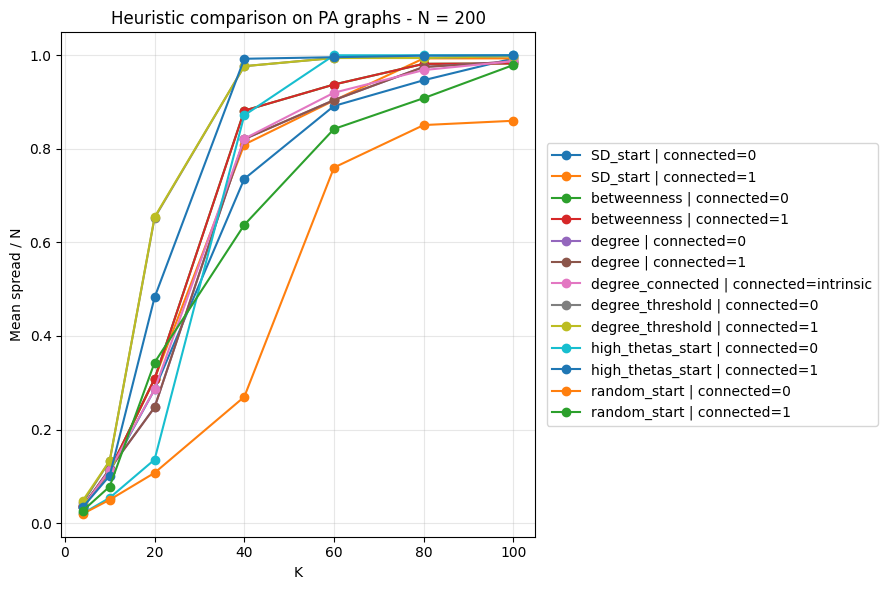

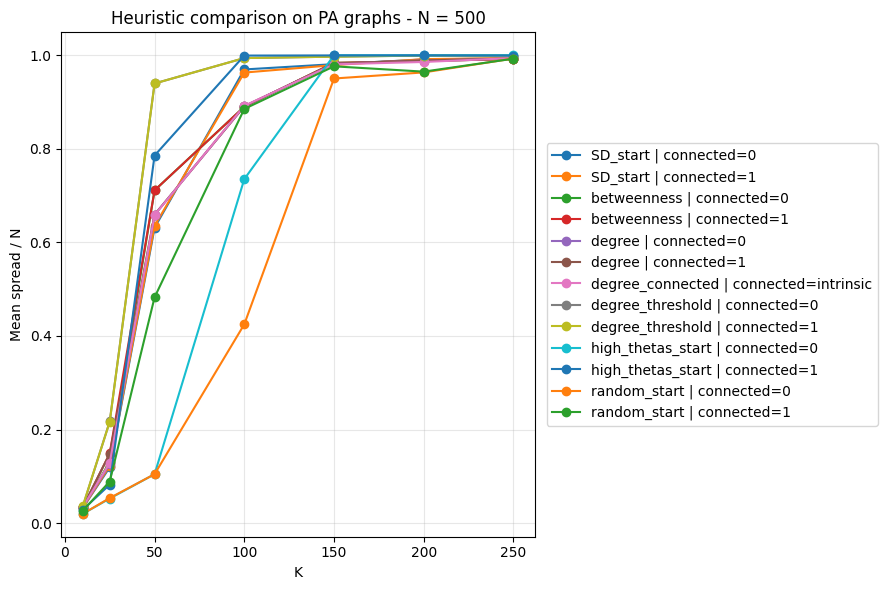

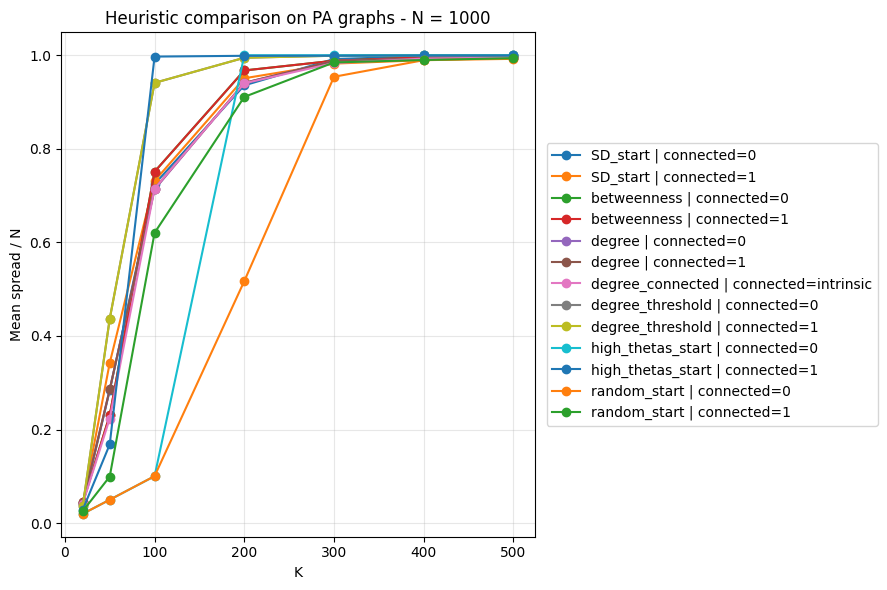

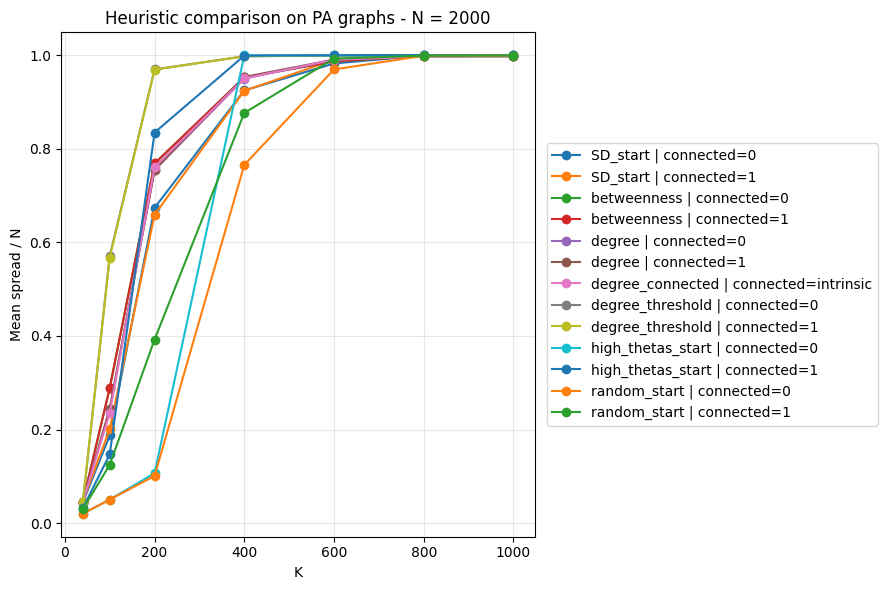

,heuristic_variant,mean_spread_ratio,mean_runtime_s
8,degree_threshold | connected=1,0.748902,0.010519
7,degree_threshold | connected=0,0.748670,0.008860
10,high_thetas_start | connected=1,0.703723,0.019879
3,betweenness | connected=1,0.678726,1.154687
2,betweenness | connected=0,0.678012,1.147195
5,degree | connected=1,0.668821,0.011979
1,SD_start | connected=1,0.668723,0.041150
4,degree | connected=0,0.667753,0.011484
6,degree_connected | connected=intrinsic,0.666955,0.258440
0,SD_start | connected=0,0.660688,0.027027


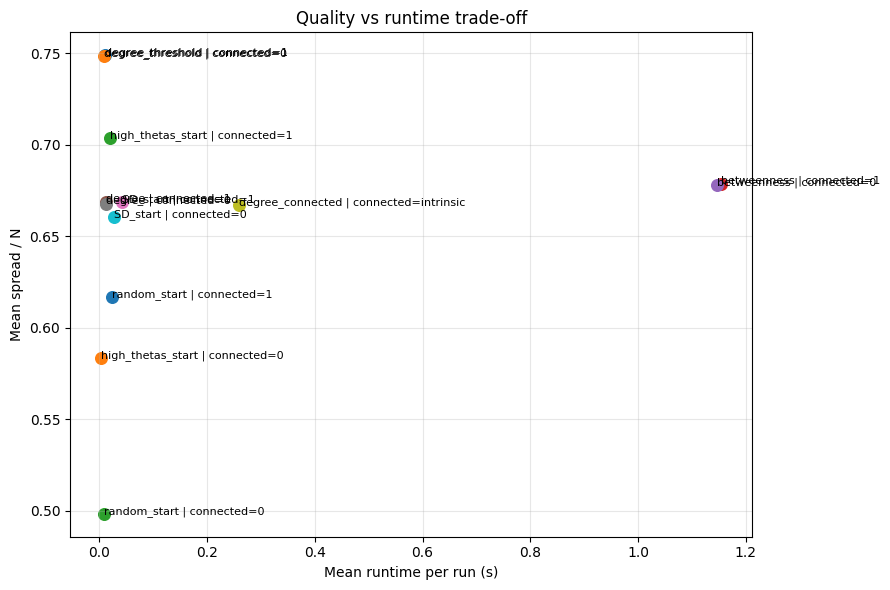

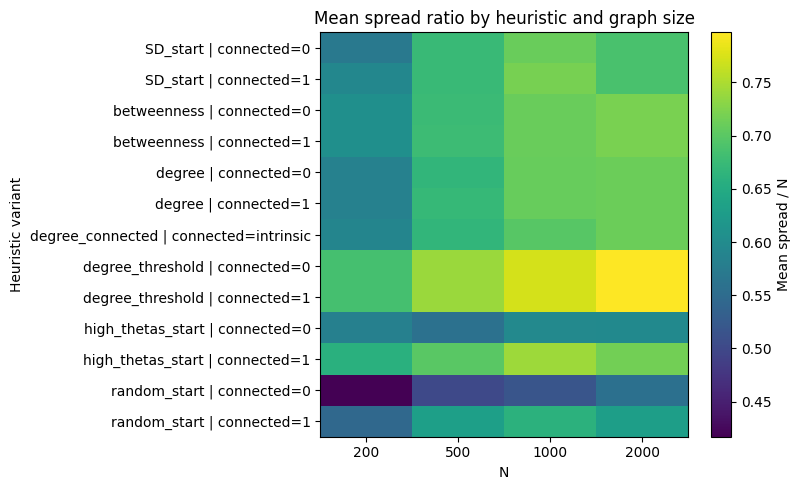

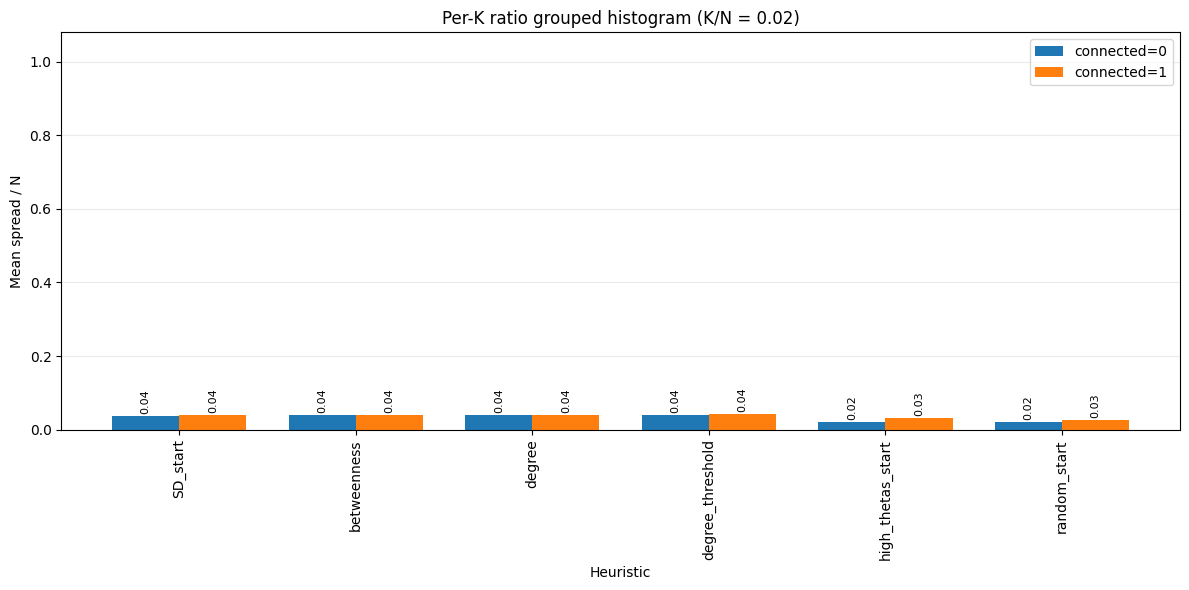

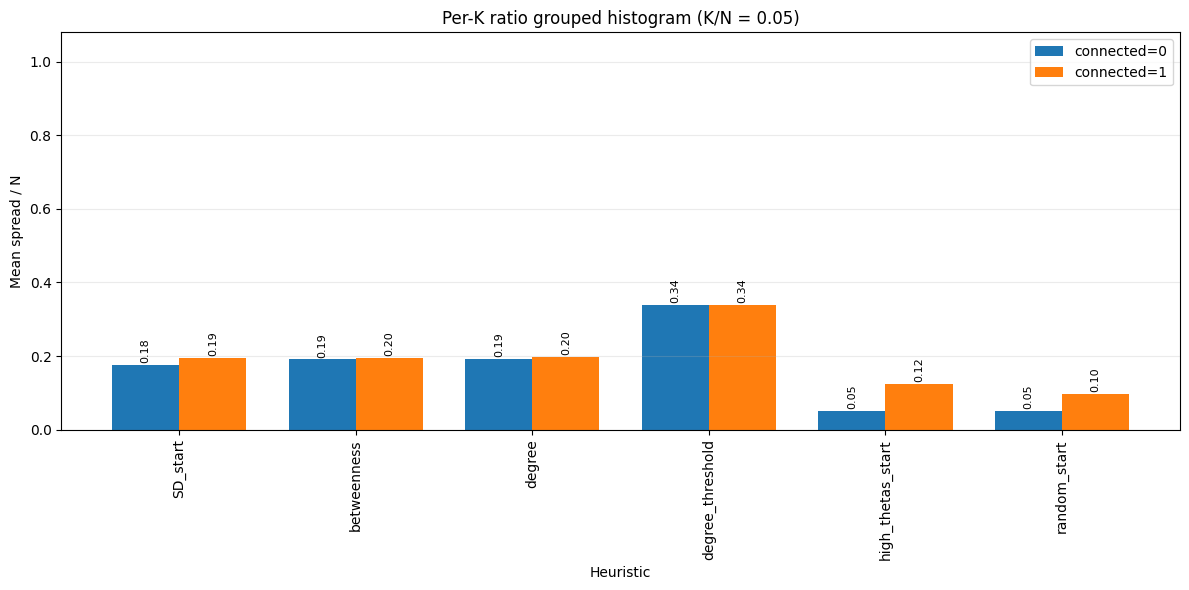

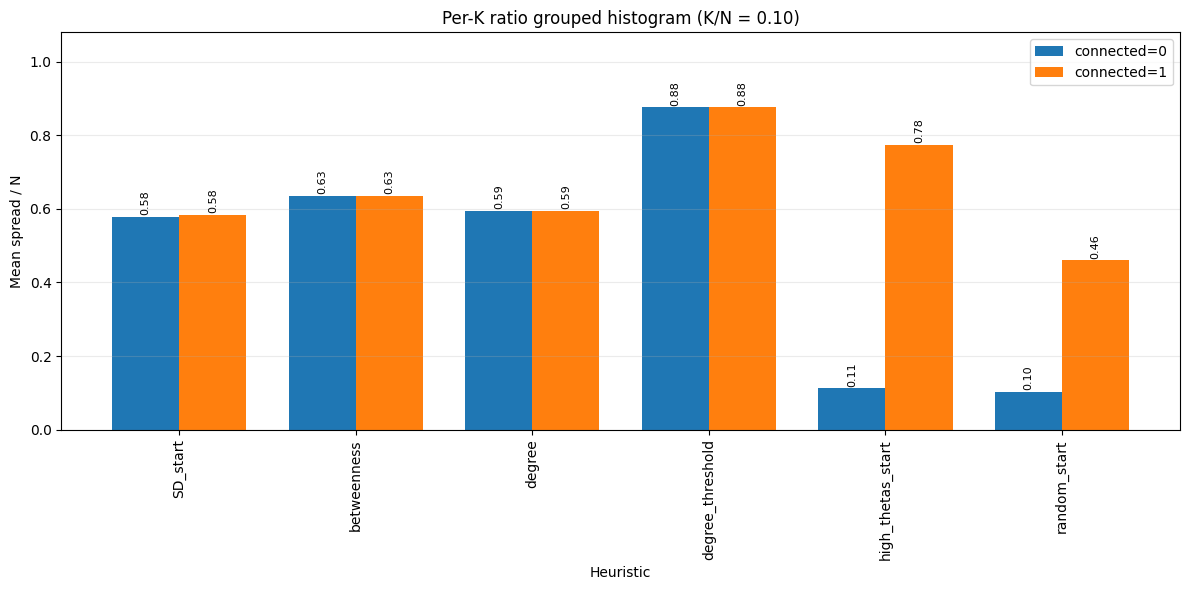

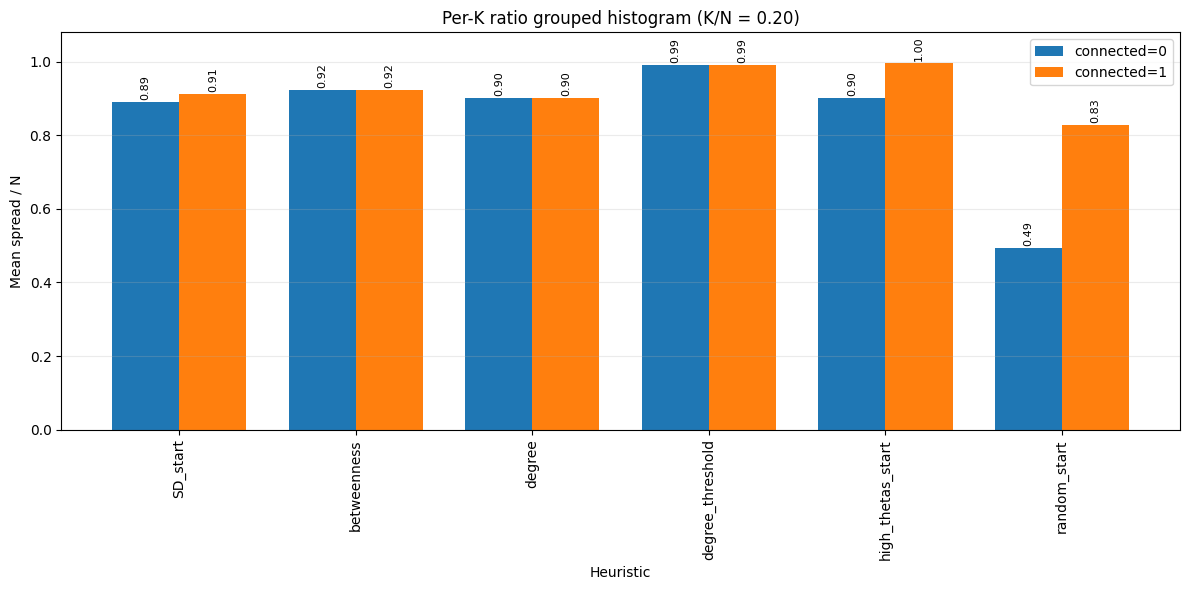

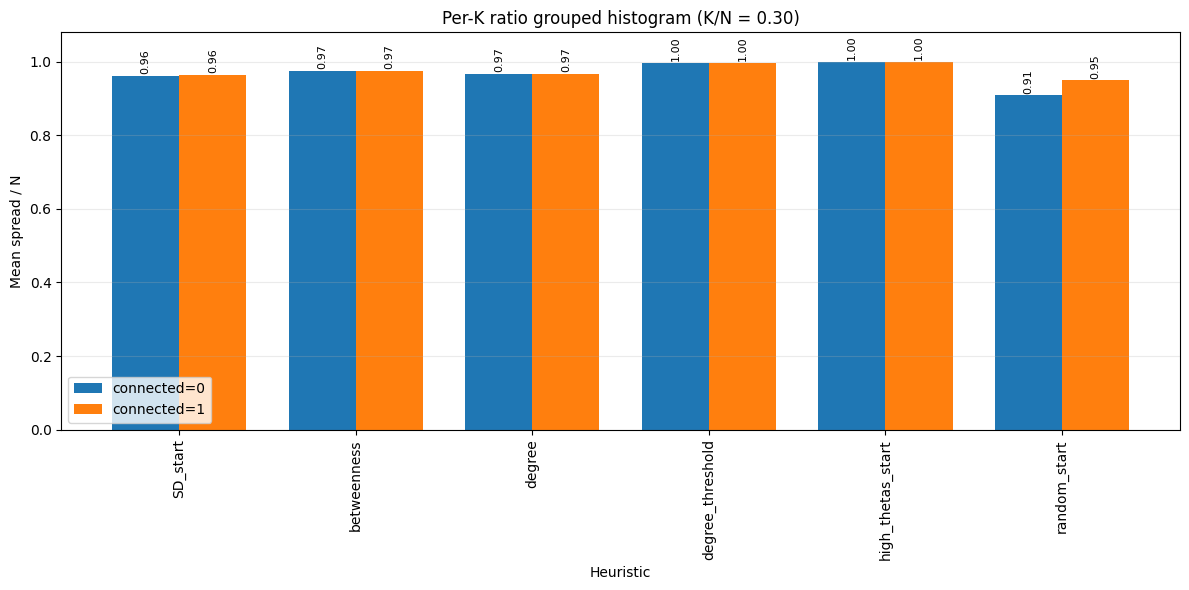

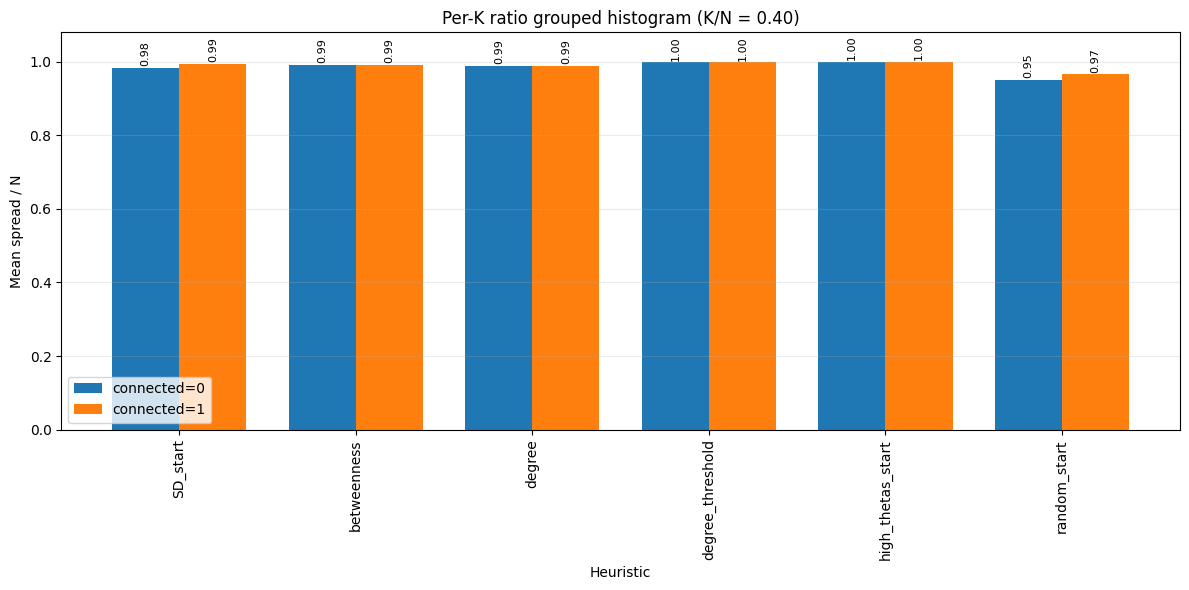

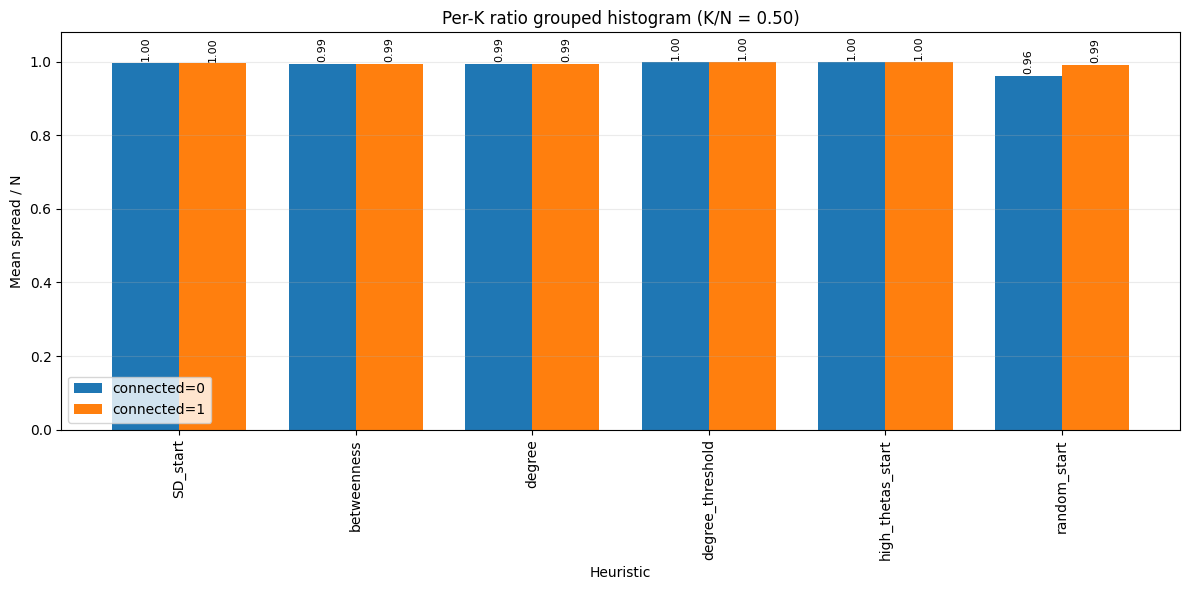

In [23]:
# Summaries + visualization (spread + time)
if "results_heuristics_df" not in globals() or results_heuristics_df.empty:
    raise ValueError("Run the benchmark cell first to populate results_heuristics_df.")

summary_df = (
    results_heuristics_df
    .groupby(["N", "K", "K_over_N", "heuristic_variant"], as_index=False)
    .agg(
        mean_spread=("spread", "mean"),
        std_spread=("spread", "std"),
        mean_spread_ratio=("spread_ratio", "mean"),
        mean_runtime_s=("runtime_s", "mean"),
        n_runs=("spread", "count"),
    )
    .sort_values(["N", "K", "mean_spread_ratio"], ascending=[True, True, False])
)

print("Top variants by (N, K):")
top_by_group = summary_df.groupby(["N", "K"], as_index=False).head(3)
display(top_by_group)

print("Average performance across all settings:")
overall_df = (
    results_heuristics_df
    .groupby("heuristic_variant", as_index=False)
    .agg(
        mean_spread_ratio=("spread_ratio", "mean"),
        std_spread_ratio=("spread_ratio", "std"),
        mean_runtime_s=("runtime_s", "mean"),
        n_runs=("spread_ratio", "count"),
    )
    .sort_values("mean_spread_ratio", ascending=False)
)
display(overall_df)

# Plot 1: mean spread ratio vs K (one separate figure per N)
N_values = sorted(results_heuristics_df["N"].unique())
for N in N_values:
    plt.figure(figsize=(9, 6))
    data_N = summary_df[summary_df["N"] == N]

    for hv, sub in data_N.groupby("heuristic_variant"):
        sub = sub.sort_values("K")
        plt.plot(sub["K"], sub["mean_spread_ratio"], marker="o", label=hv)

    plt.title(f"Heuristic comparison on PA graphs - N = {N}")
    plt.xlabel("K")
    plt.ylabel("Mean spread / N")
    plt.grid(alpha=0.3)
    plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.tight_layout()
    plt.show()

# Plot 2: quality vs time trade-off
tradeoff = (
    results_heuristics_df
    .groupby("heuristic_variant", as_index=False)
    .agg(
        mean_spread_ratio=("spread_ratio", "mean"),
        mean_runtime_s=("runtime_s", "mean"),
    )
    .sort_values("mean_spread_ratio", ascending=False)
)

display(tradeoff)

plt.figure(figsize=(9, 6))
for _, row in tradeoff.iterrows():
    plt.scatter(row["mean_runtime_s"], row["mean_spread_ratio"], s=70)
    plt.text(row["mean_runtime_s"], row["mean_spread_ratio"], row["heuristic_variant"], fontsize=8)

plt.xlabel("Mean runtime per run (s)")
plt.ylabel("Mean spread / N")
plt.title("Quality vs runtime trade-off")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: heatmap-like table of mean spread ratio by heuristic and N
heat_df = (
    results_heuristics_df
    .groupby(["heuristic_variant", "N"], as_index=False)["spread_ratio"]
    .mean()
    .pivot(index="heuristic_variant", columns="N", values="spread_ratio")
    .sort_index()
)

plt.figure(figsize=(8, max(5, 0.35 * len(heat_df))))
plt.imshow(heat_df.values, aspect="auto")
plt.xticks(range(len(heat_df.columns)), heat_df.columns)
plt.yticks(range(len(heat_df.index)), heat_df.index)
plt.colorbar(label="Mean spread / N")
plt.title("Mean spread ratio by heuristic and graph size")
plt.xlabel("N")
plt.ylabel("Heuristic variant")
plt.tight_layout()
plt.show()

# Plot 4: one grouped histogram per K ratio (separate figure for each K/N)
bar_df = results_heuristics_df[results_heuristics_df["connected"].isin(["0", "1"])].copy()

if bar_df.empty:
    print("No connected/non-connected pairs available for grouped histograms.")
else:
    agg_ratio = (
        bar_df
        .groupby(["K_over_N", "heuristic", "connected"], as_index=False)["spread_ratio"]
        .mean()
    )

    k_ratio_values = sorted(agg_ratio["K_over_N"].unique())
    heuristics_order = sorted(agg_ratio["heuristic"].unique())

    bar_width = 0.38

    for k_ratio in k_ratio_values:
        sub = agg_ratio[np.isclose(agg_ratio["K_over_N"], k_ratio)]

        y_conn0 = []
        y_conn1 = []
        for h in heuristics_order:
            v0 = sub[(sub["heuristic"] == h) & (sub["connected"] == "0")]["spread_ratio"]
            v1 = sub[(sub["heuristic"] == h) & (sub["connected"] == "1")]["spread_ratio"]
            y_conn0.append(float(v0.iloc[0]) if len(v0) else 0.0)
            y_conn1.append(float(v1.iloc[0]) if len(v1) else 0.0)

        x = np.arange(len(heuristics_order))

        plt.figure(figsize=(12, 6))
        bars0 = plt.bar(x - bar_width / 2, y_conn0, width=bar_width, label="connected=0")
        bars1 = plt.bar(x + bar_width / 2, y_conn1, width=bar_width, label="connected=1")

        for rect in list(bars0) + list(bars1):
            h = rect.get_height()
            plt.text(
                rect.get_x() + rect.get_width() / 2,
                h + 0.005,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

        plt.title(f"Per-K ratio grouped histogram (K/N = {k_ratio:.2f})")
        plt.xticks(x, heuristics_order, rotation=90)
        plt.xlabel("Heuristic")
        plt.ylabel("Mean spread / N")
        plt.ylim(0, 1.08)
        plt.grid(axis="y", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()